In [1]:
import jax.random as jrd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl

## Simple replacement

In [2]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(1.0, name="scale")

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False

W0508 09:25:32.492767 4054213 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


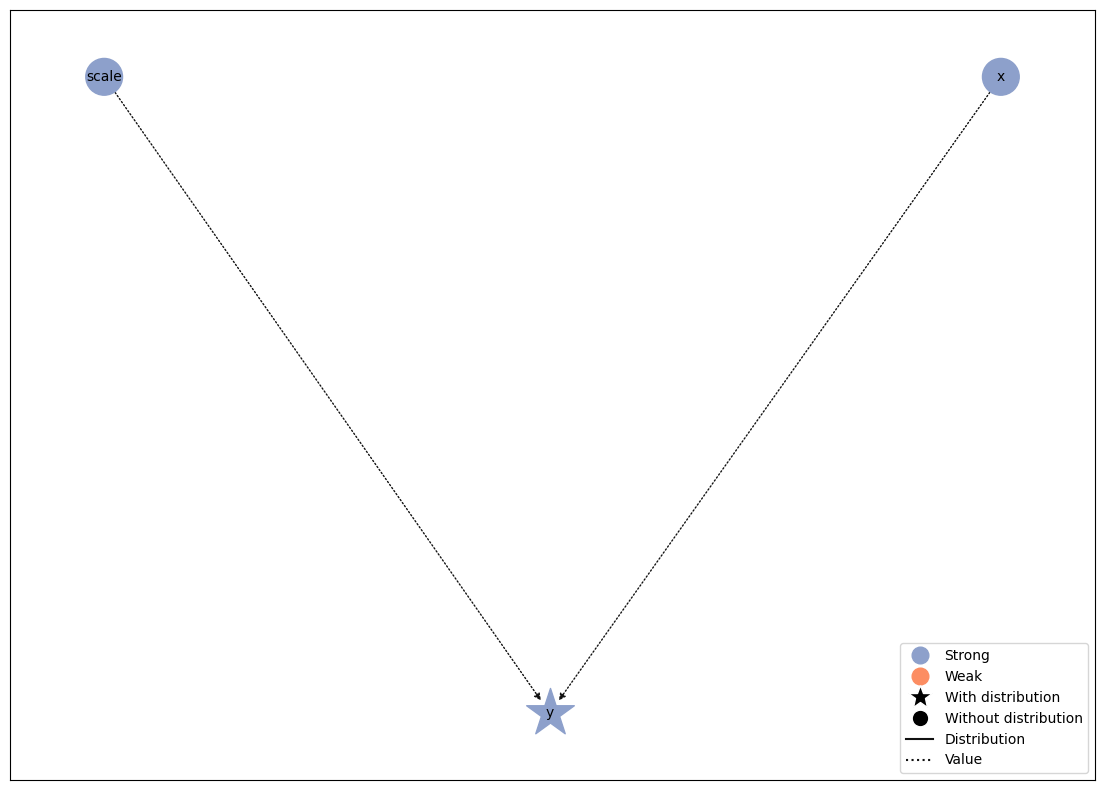

In [3]:
model.plot_vars()

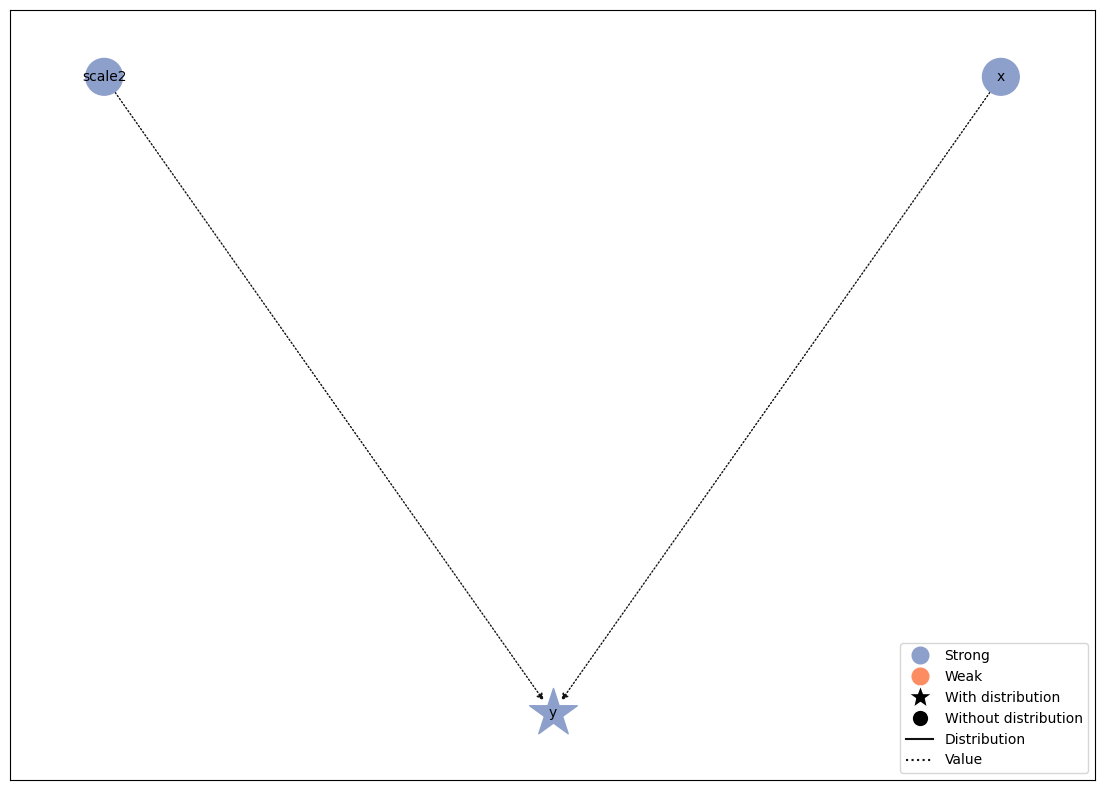

In [4]:
scale2 = lsl.Var.new_param(2.0, name="scale2")
model.replace("scale", scale2)
model.plot_vars()

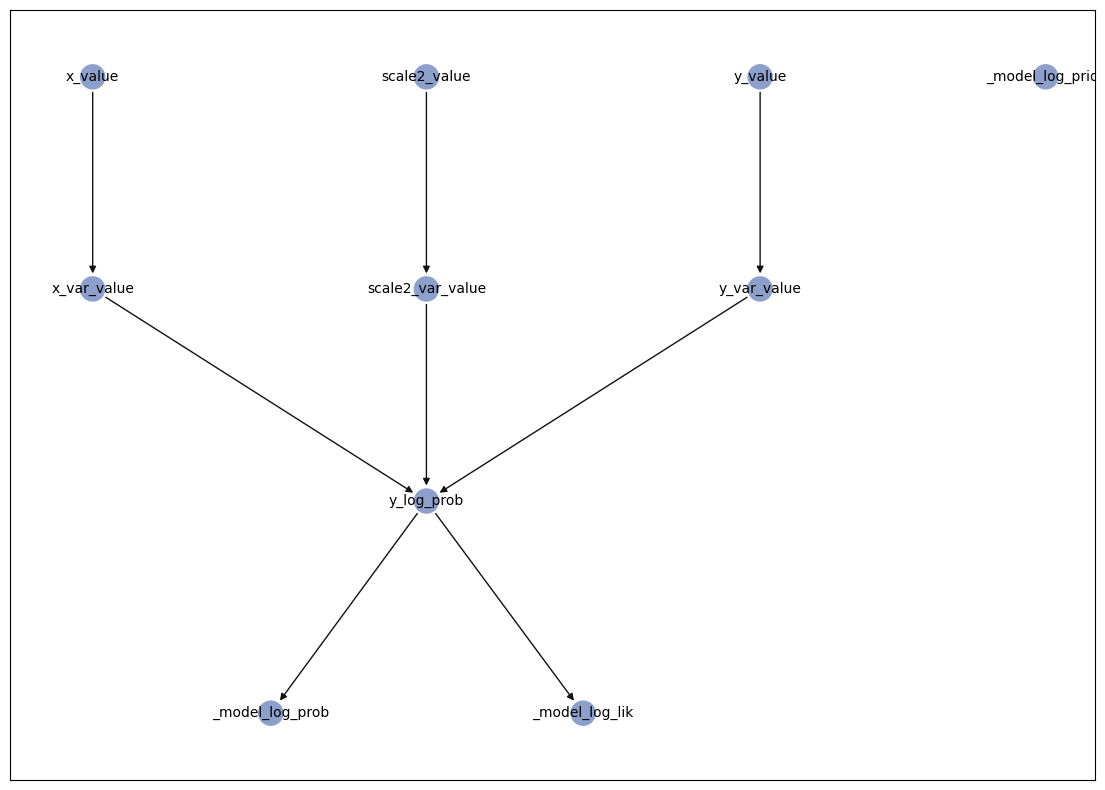

In [5]:
model.plot_nodes()

### Replace Var with itself

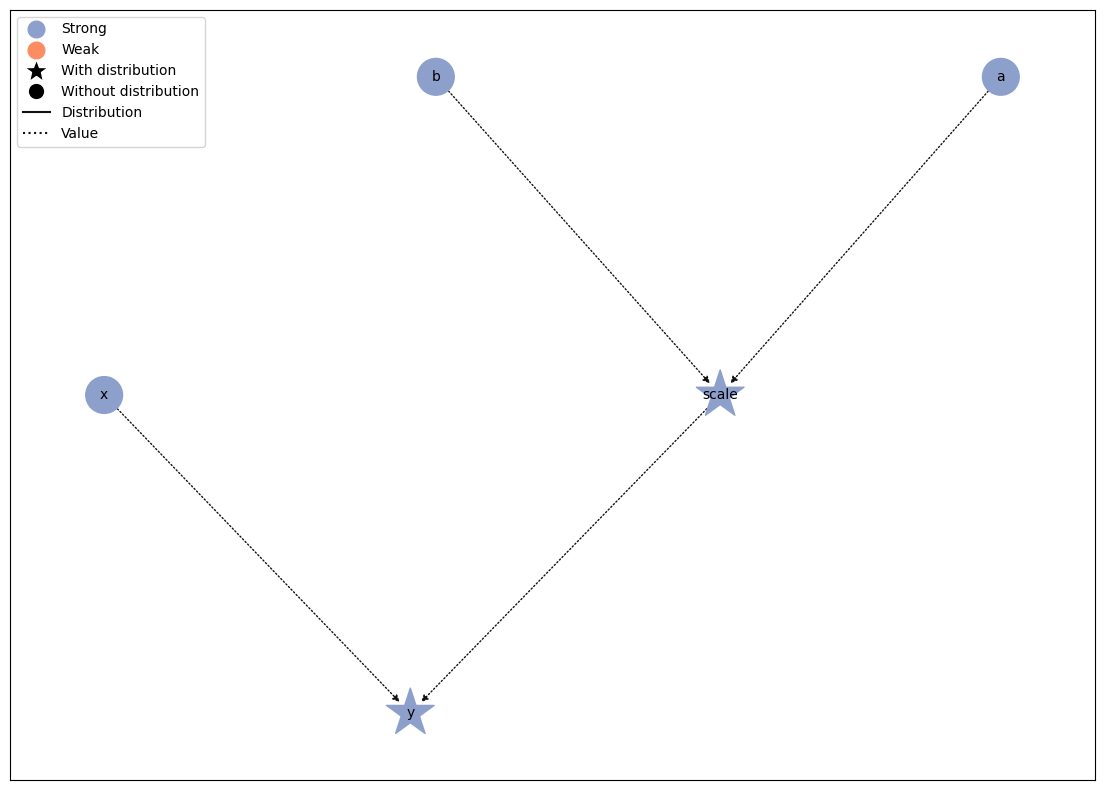

In [6]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

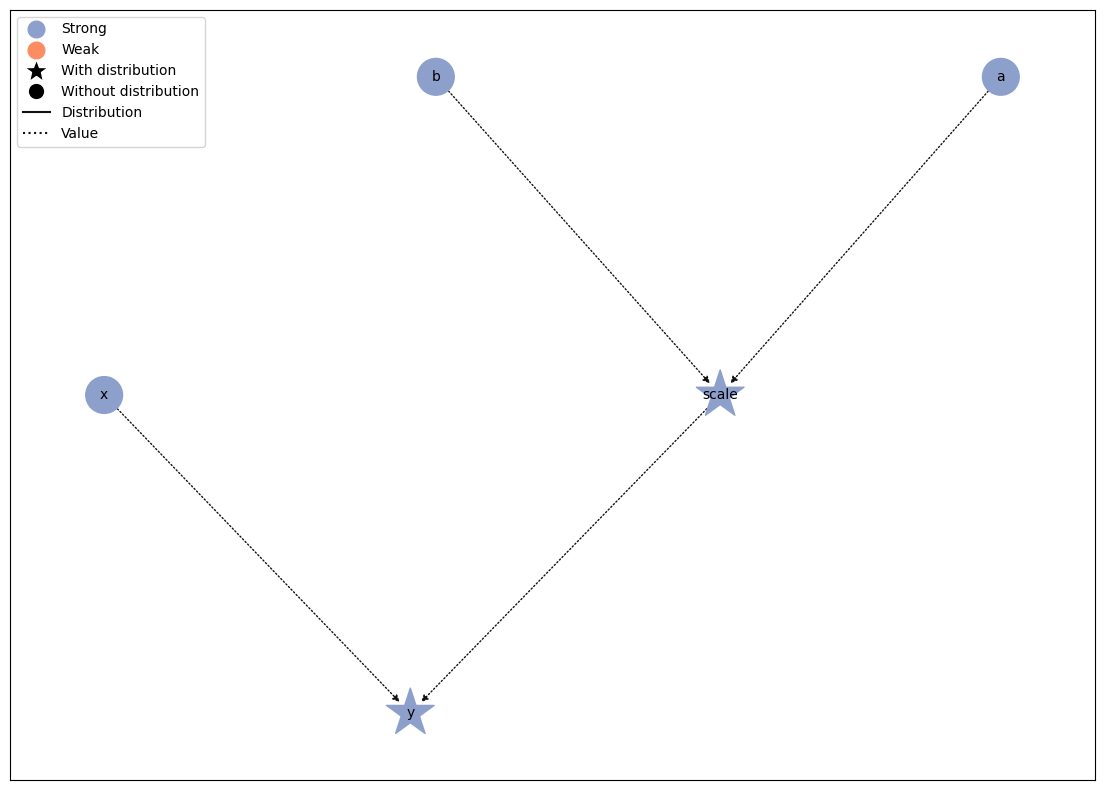

In [7]:
model.replace(scale, scale)
model.plot_vars()

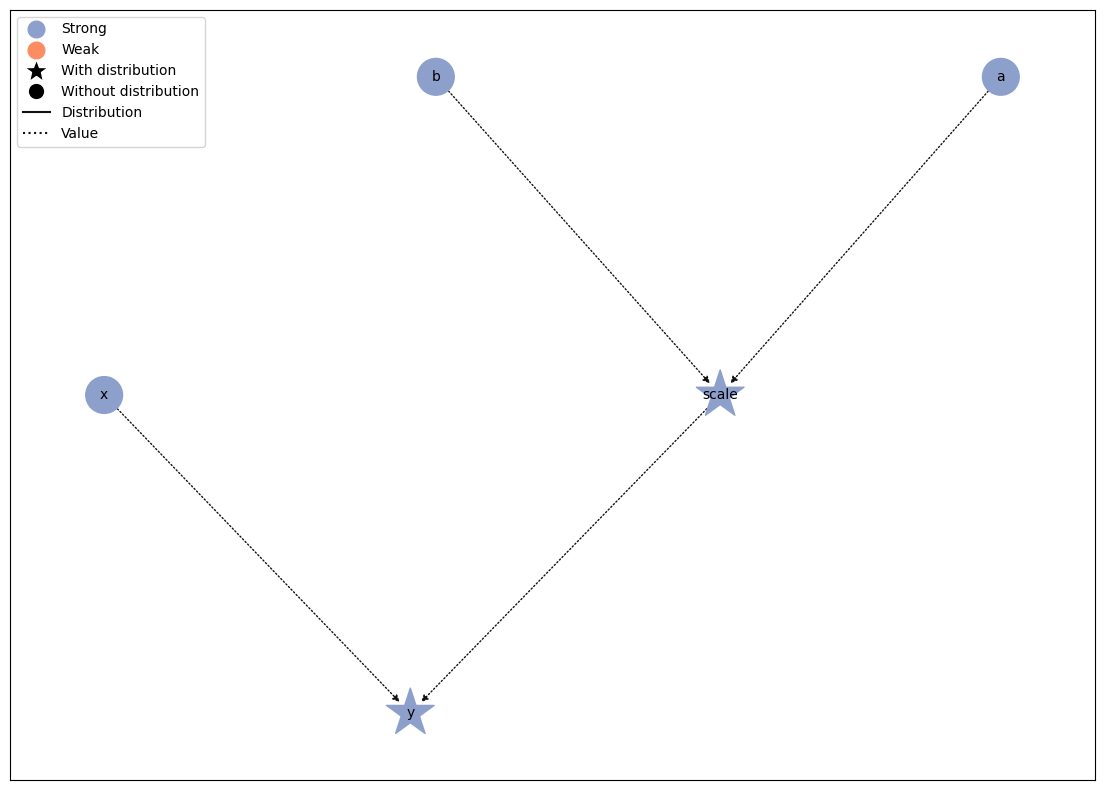

In [8]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

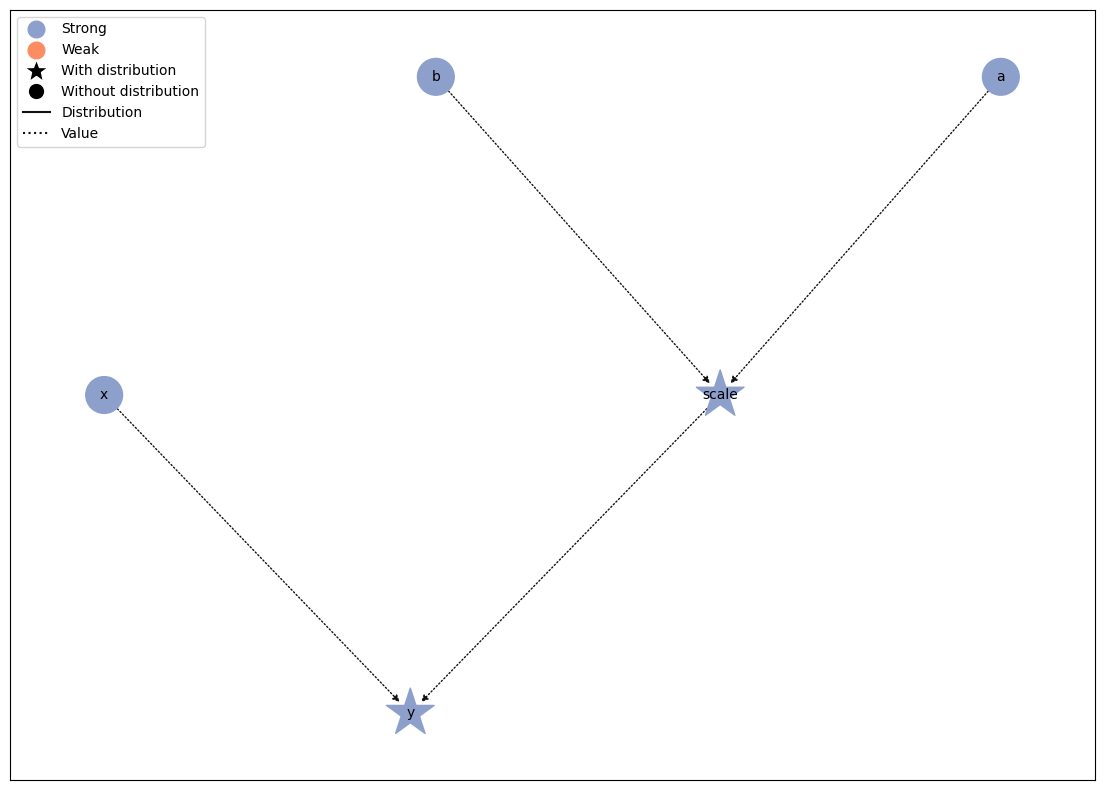

In [9]:
model.replace(y, y)
model.plot_vars()

### Replace Var with Dist and hyperparameters

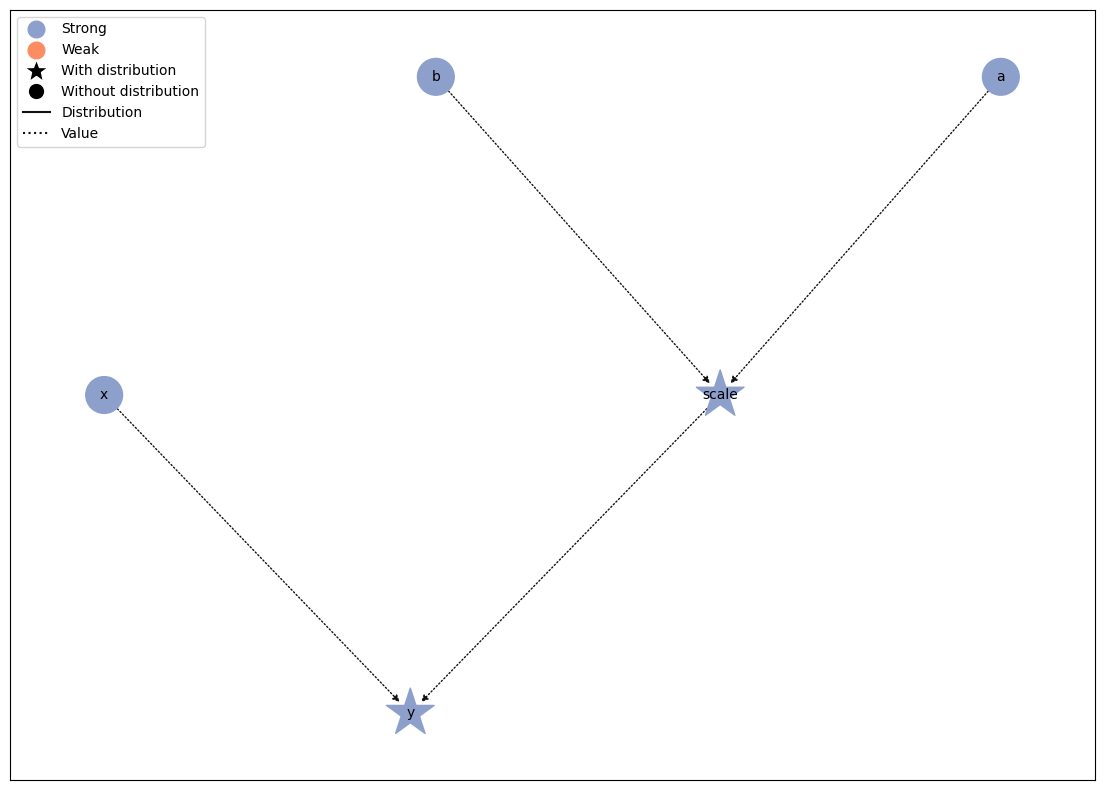

In [10]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

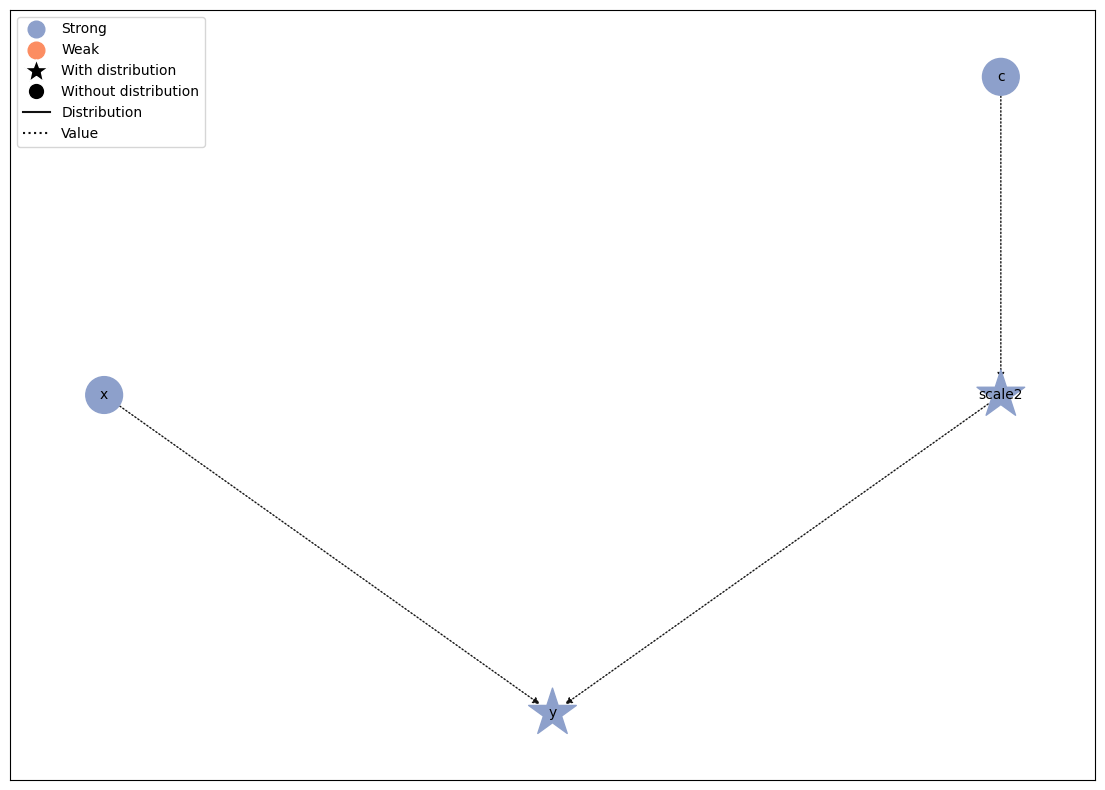

In [11]:
scale2 = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.Weibull,
        concentration=0.0,
        scale=lsl.Var.new_param(1.0, name="c"),
    ),
    name="scale2",
)

model.replace(scale, scale2)
model.plot_vars()

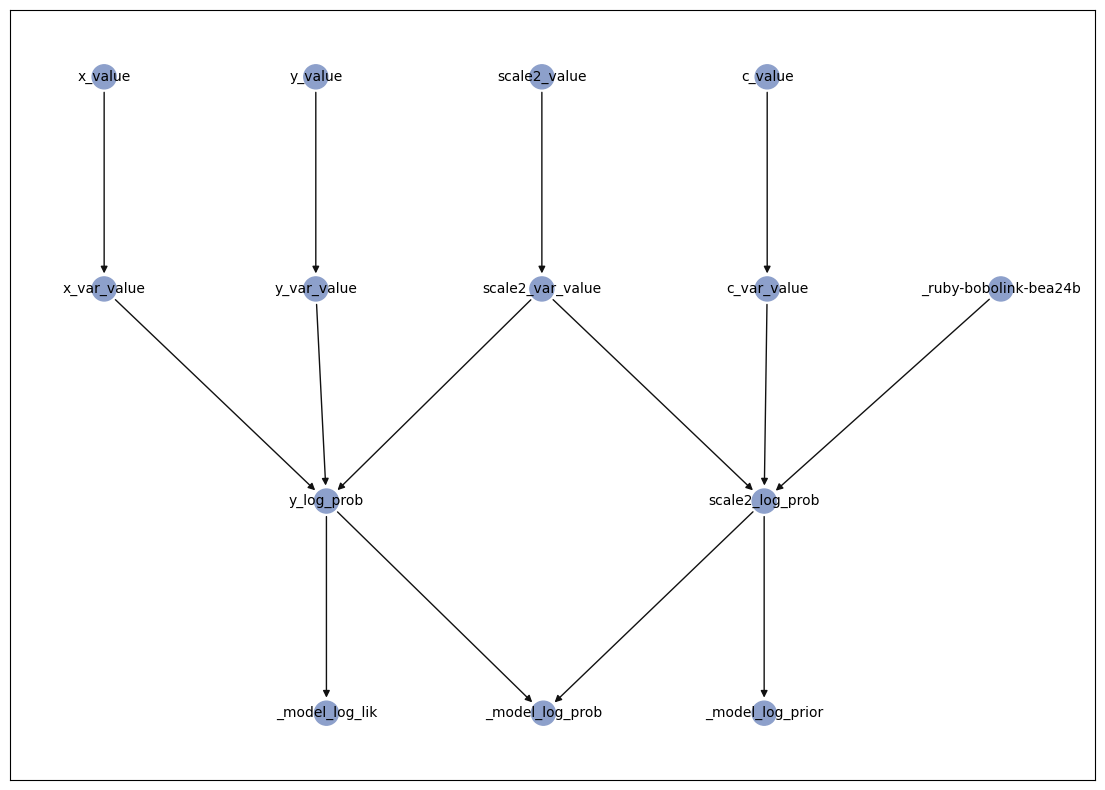

In [12]:
model.plot_nodes()

In [13]:
scale.model  # is now None

### Replace Var with Var of same name

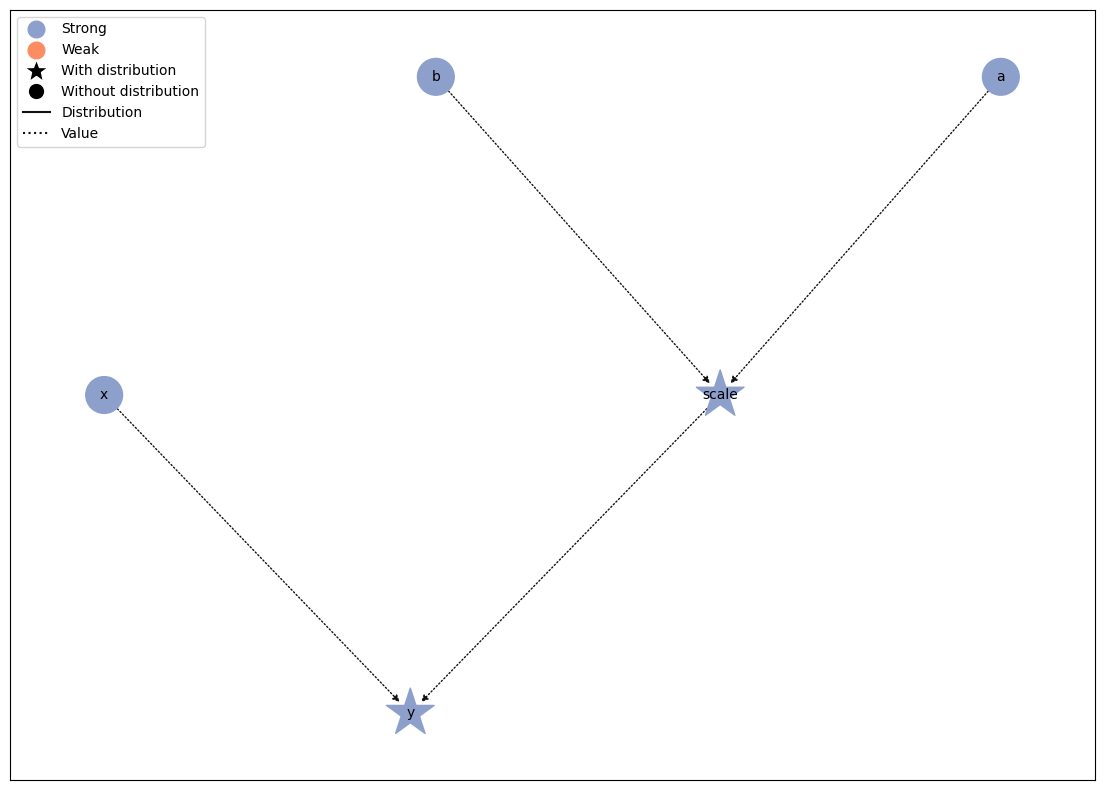

In [14]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)),
    lsl.Dist(tfd.Normal, loc=x, scale=scale),
    name="y",
)

newx = lsl.Var.new_obs(jrd.normal(jrd.key(2), (10,)), name="x")

model = lsl.Model([y])
model.locked = False

model.plot()

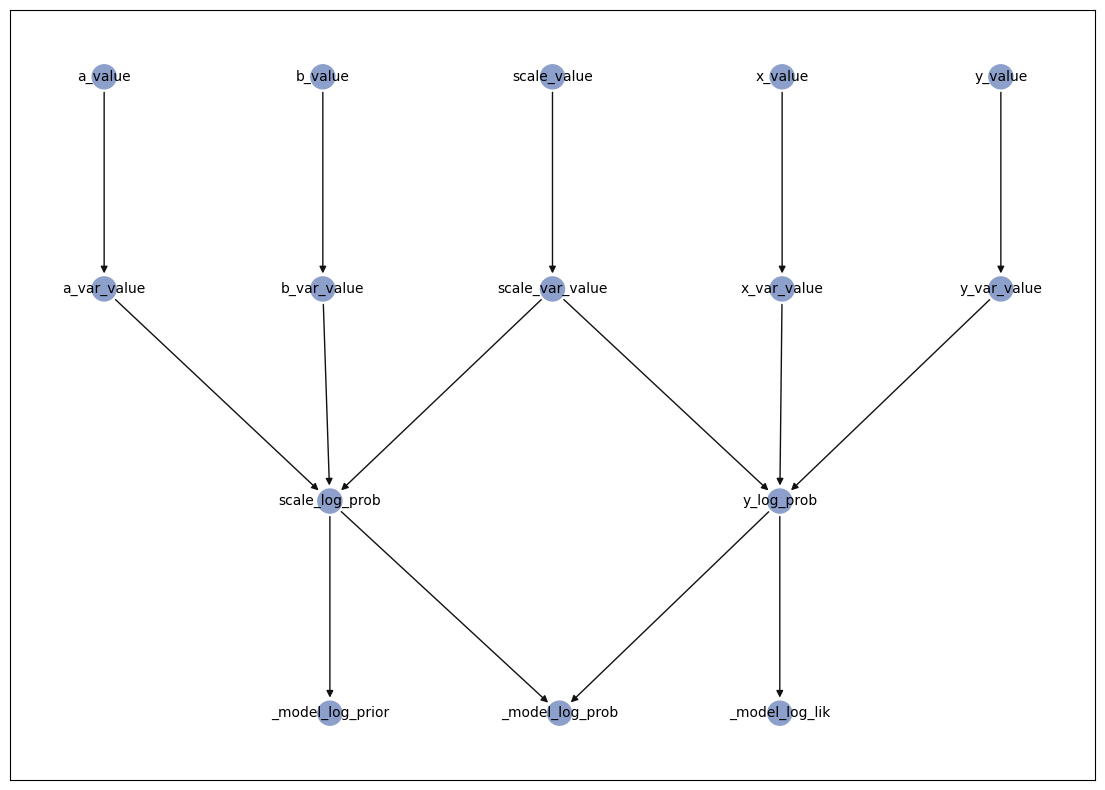

In [15]:
model.plot_nodes()

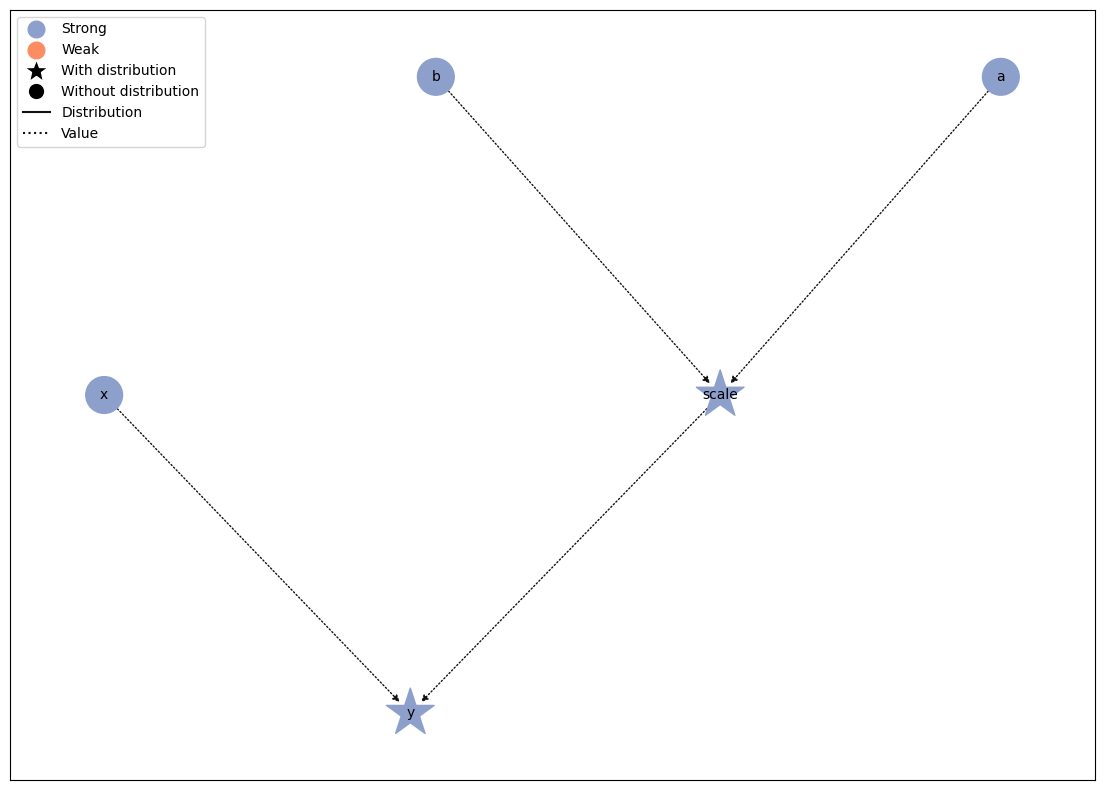

In [16]:
model.replace(x, newx)
model.plot()

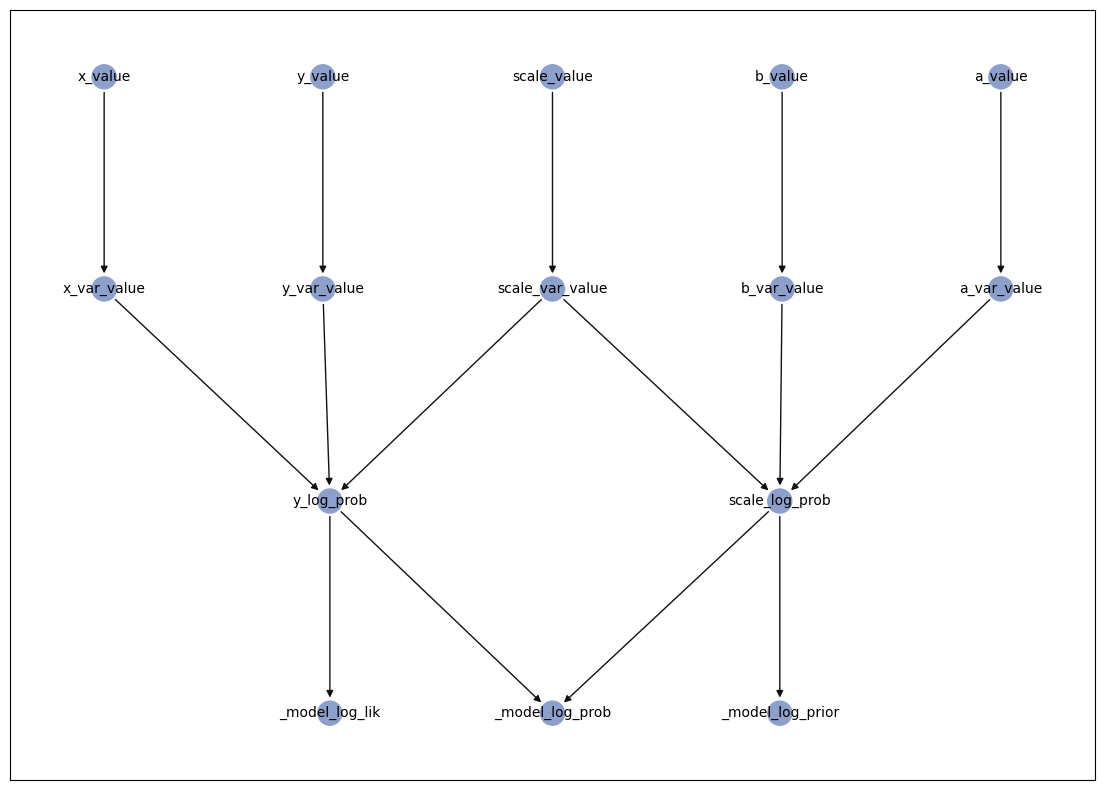

In [17]:
model.plot_nodes()

## Replace Var, creating a graph with two disconnected subgraphs

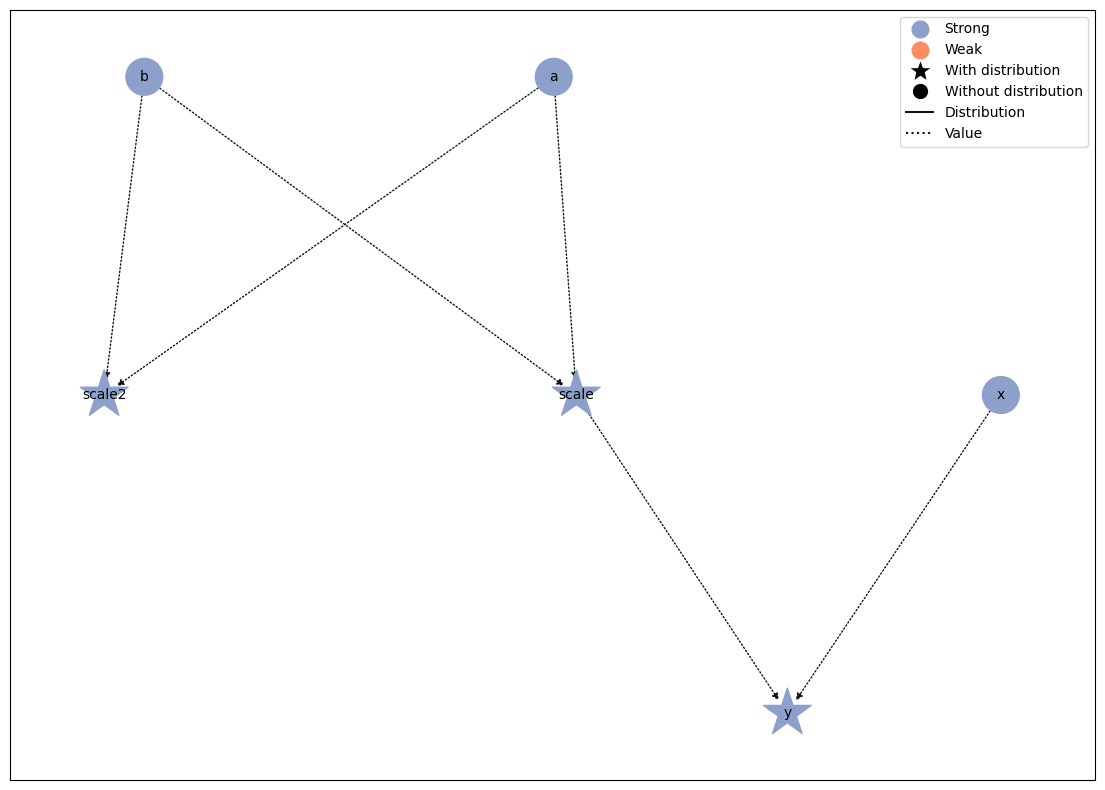

In [18]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

scale2 = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=scale.dist_node["concentration"],
        scale=scale.dist_node["scale"],
    ),
    name="scale2",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y, scale2])
model.locked = False
model.plot_vars()

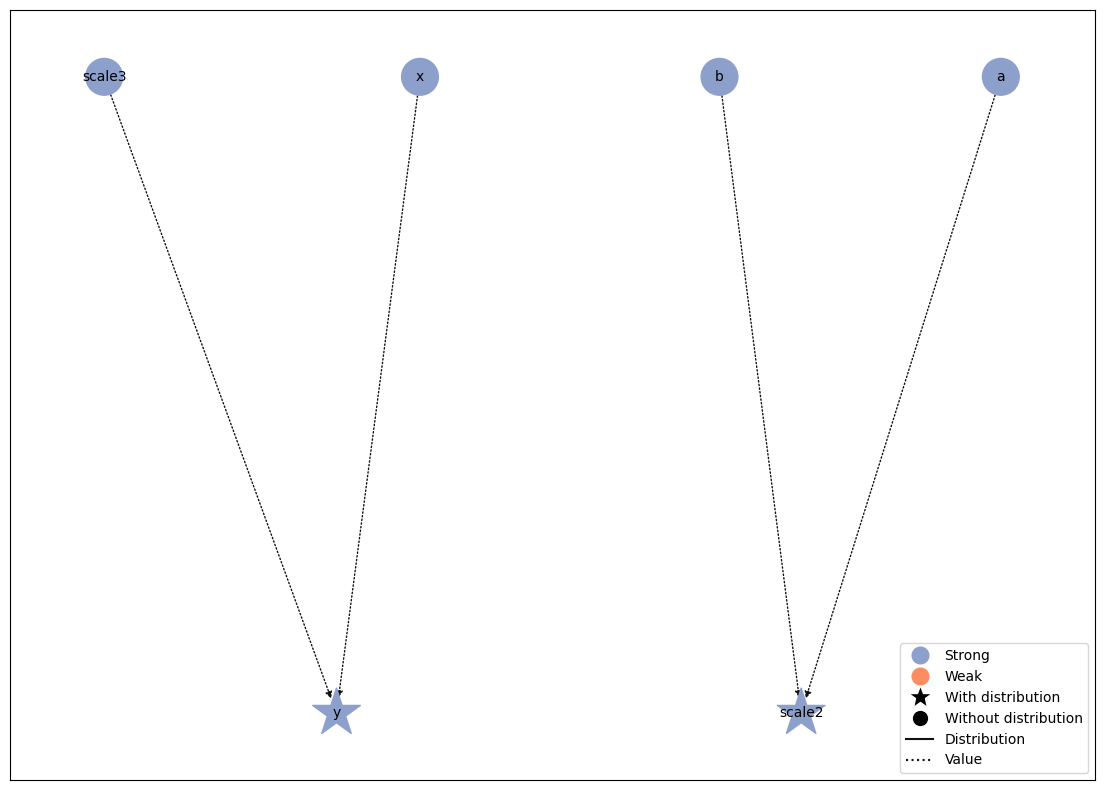

In [19]:
scale3 = lsl.Var.new_param(
    1.0,
    name="scale3",
)

model.replace(scale, scale3)
model.plot_vars()

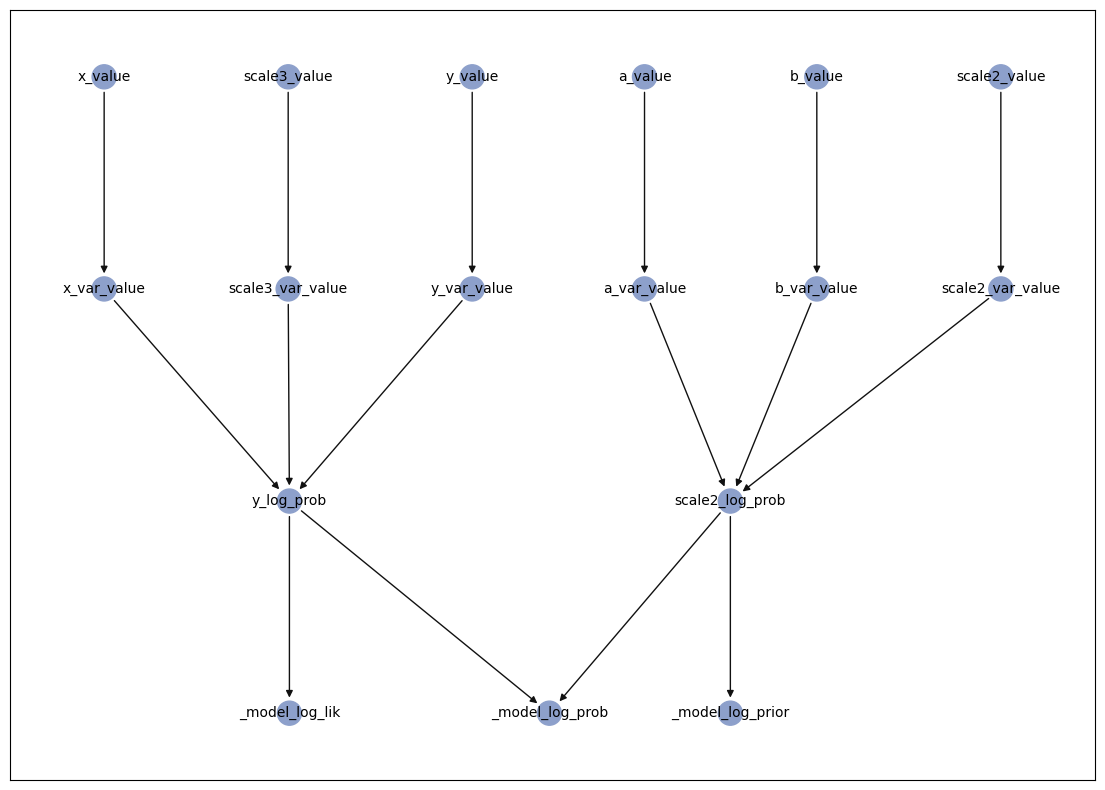

In [20]:
model.plot_nodes()

## Remove dist node

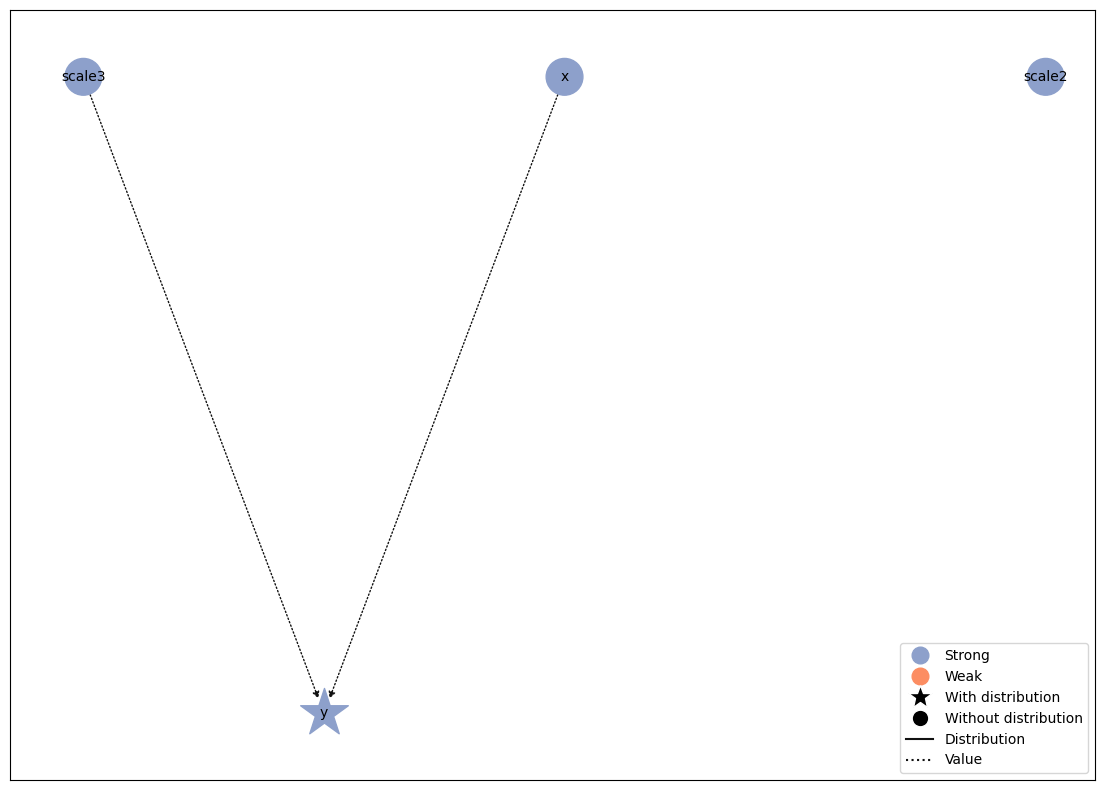

In [21]:
scale2.dist_node = None

model.plot_vars()

## Drop singletons

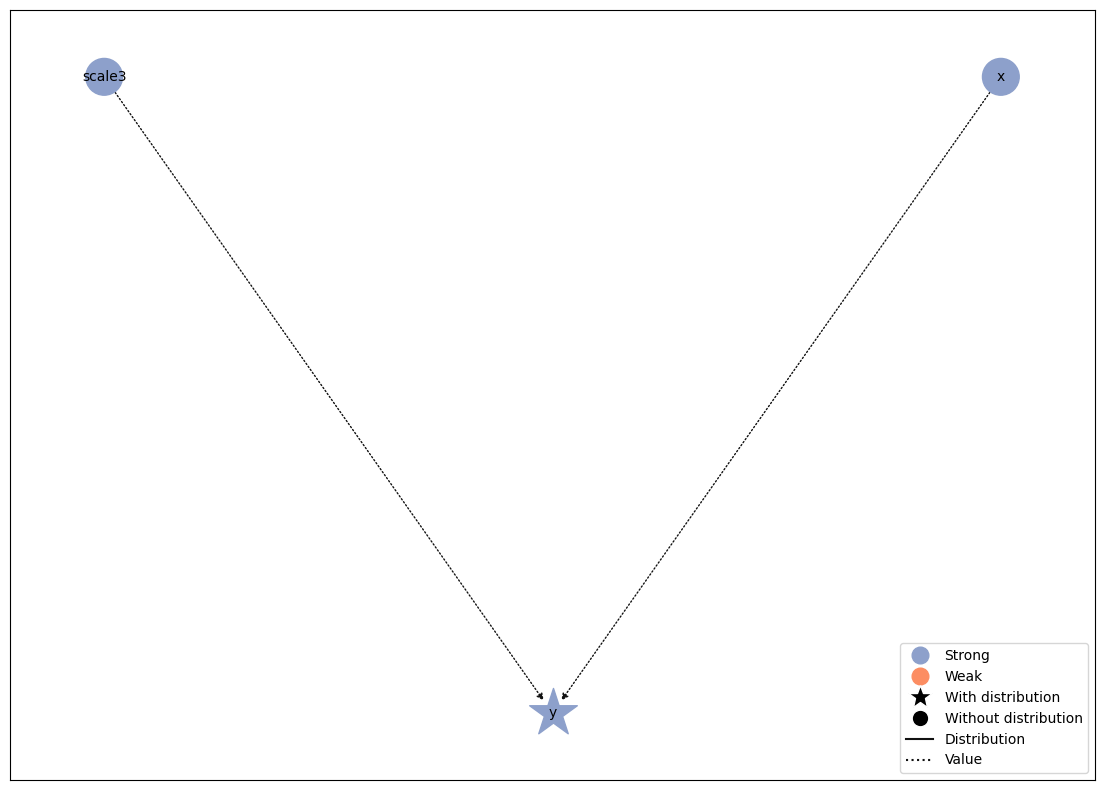

In [22]:
model.drop_singletons().plot_vars()

## Replace dist node

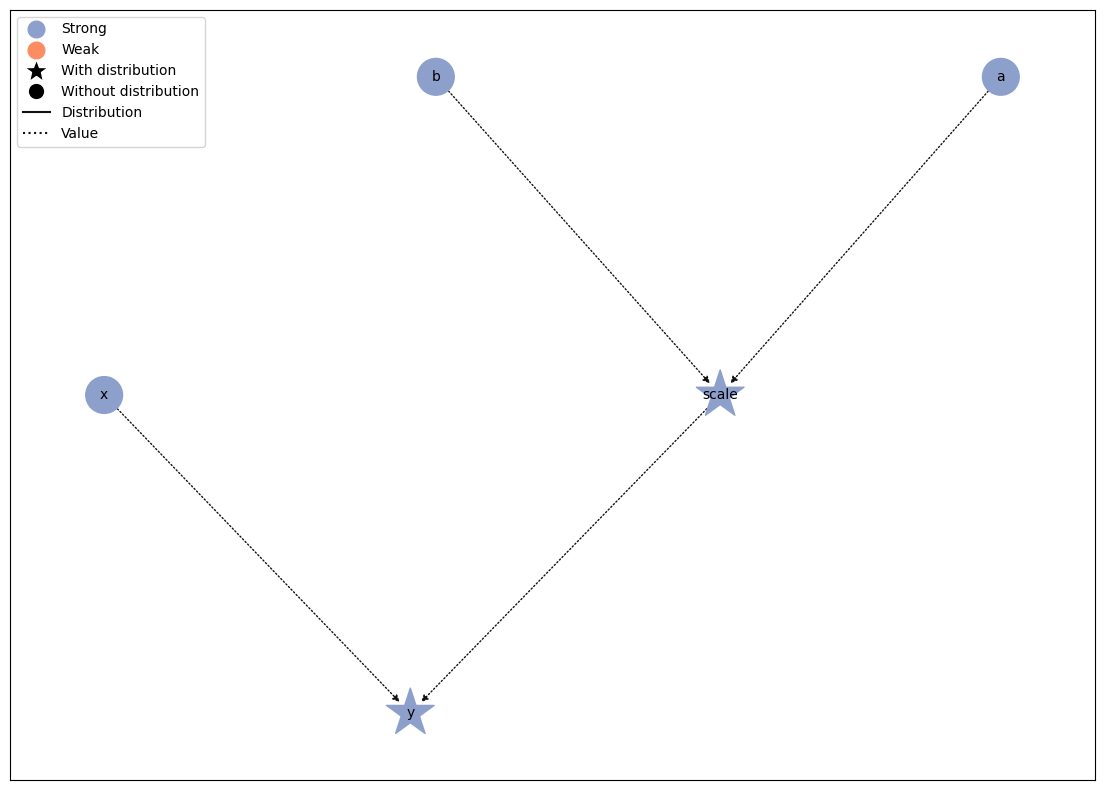

In [23]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

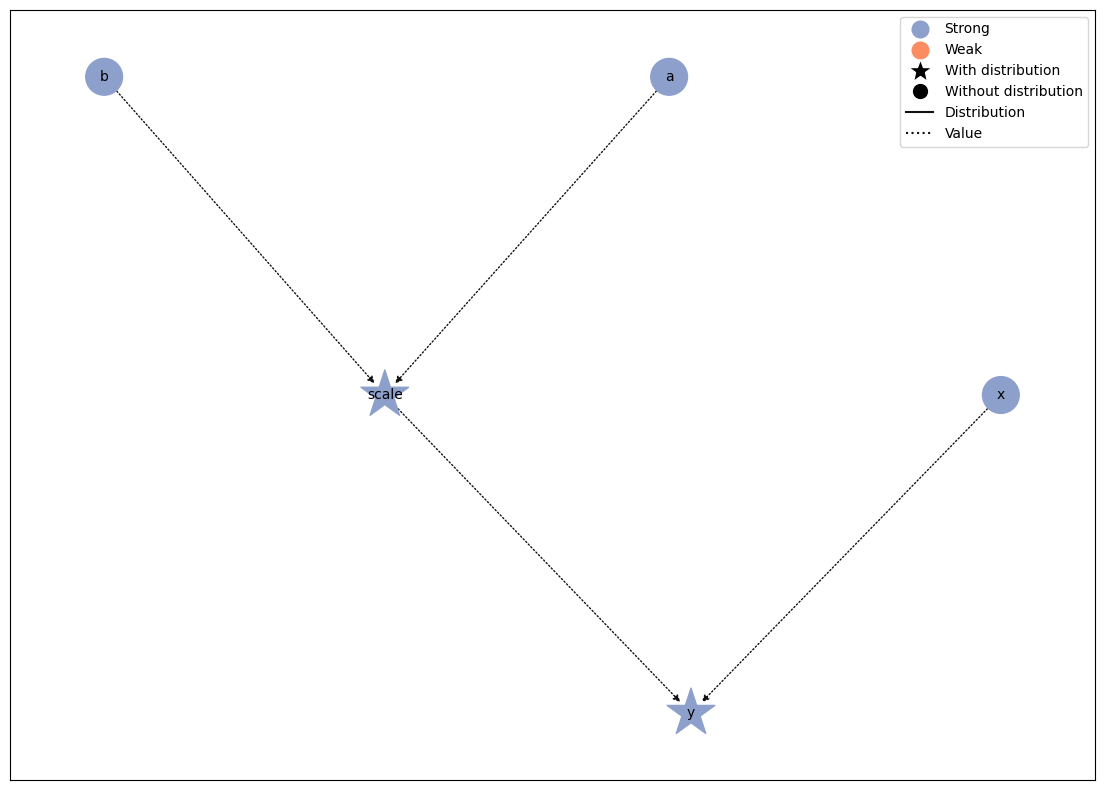

In [24]:
scale.dist_node = lsl.Dist(
    tfd.Weibull,
    concentration=lsl.Var.new_param(0.5, name="a"),
    scale=lsl.Var.new_param(2.0, name="b"),
)

model.plot_vars()

In [25]:
scale.dist_node.distribution

tensorflow_probability.substrates.jax.distributions.weibull.Weibull

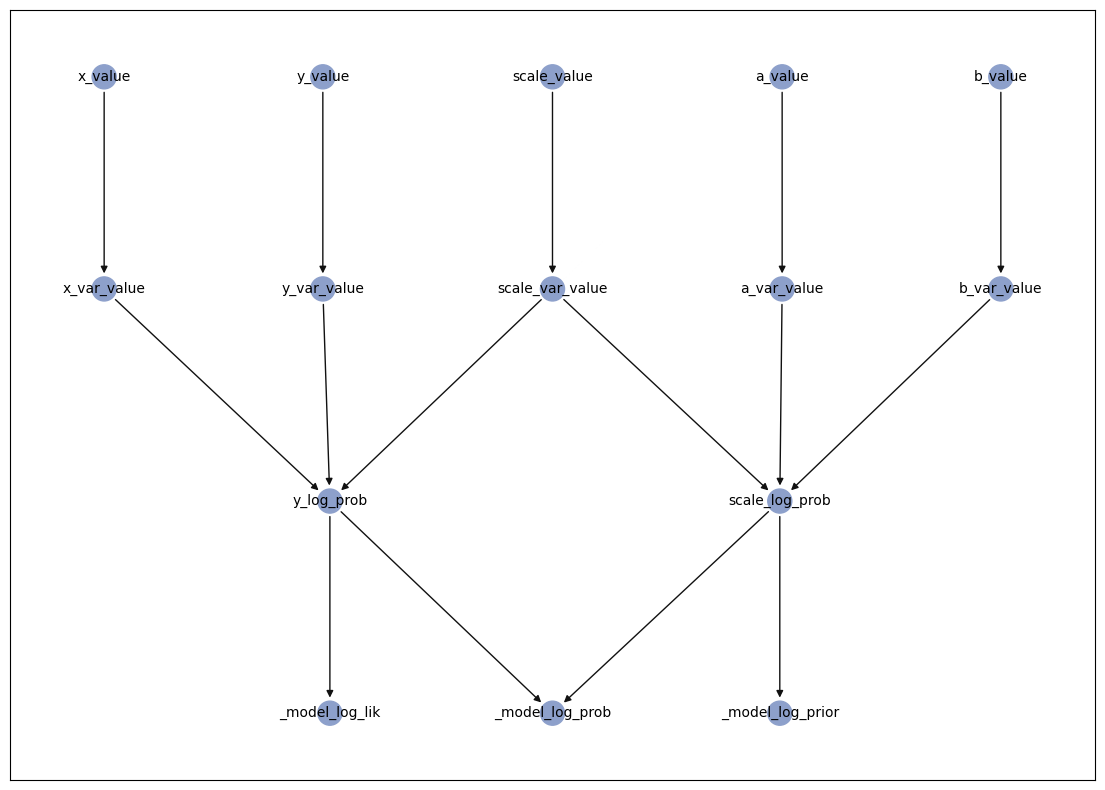

In [26]:
model.plot_nodes()

## Replace value node with unnamed node, that node's name is updated

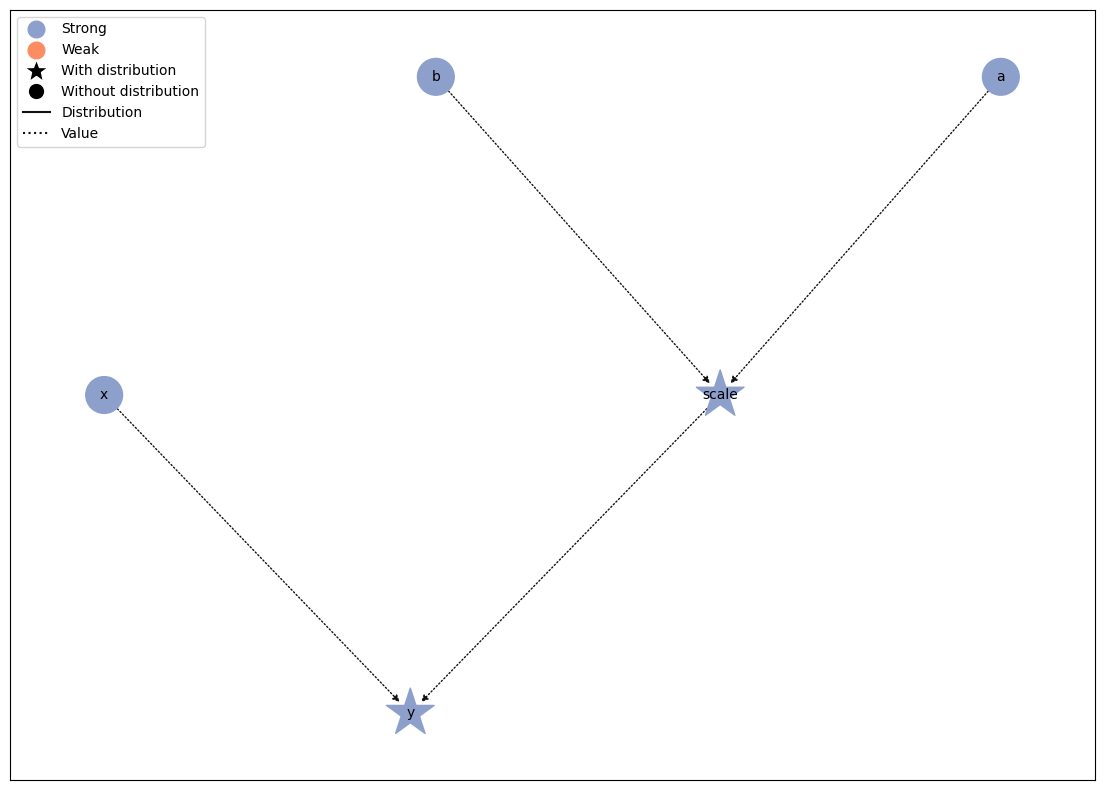

In [27]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

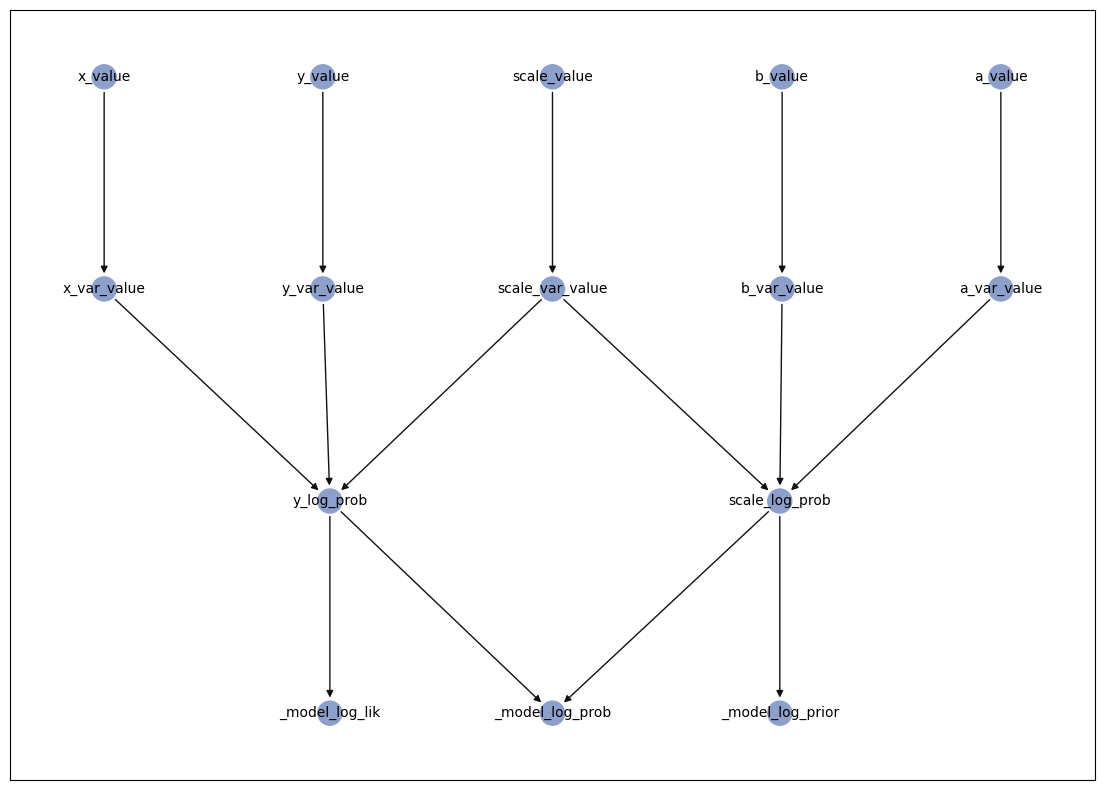

In [28]:
scale.value_node = lsl.Value(2.0)
model.plot_nodes()

In [29]:
scale.value

Array(2., dtype=float32, weak_type=True)

## Replace value node with named node, that node's name is not updated

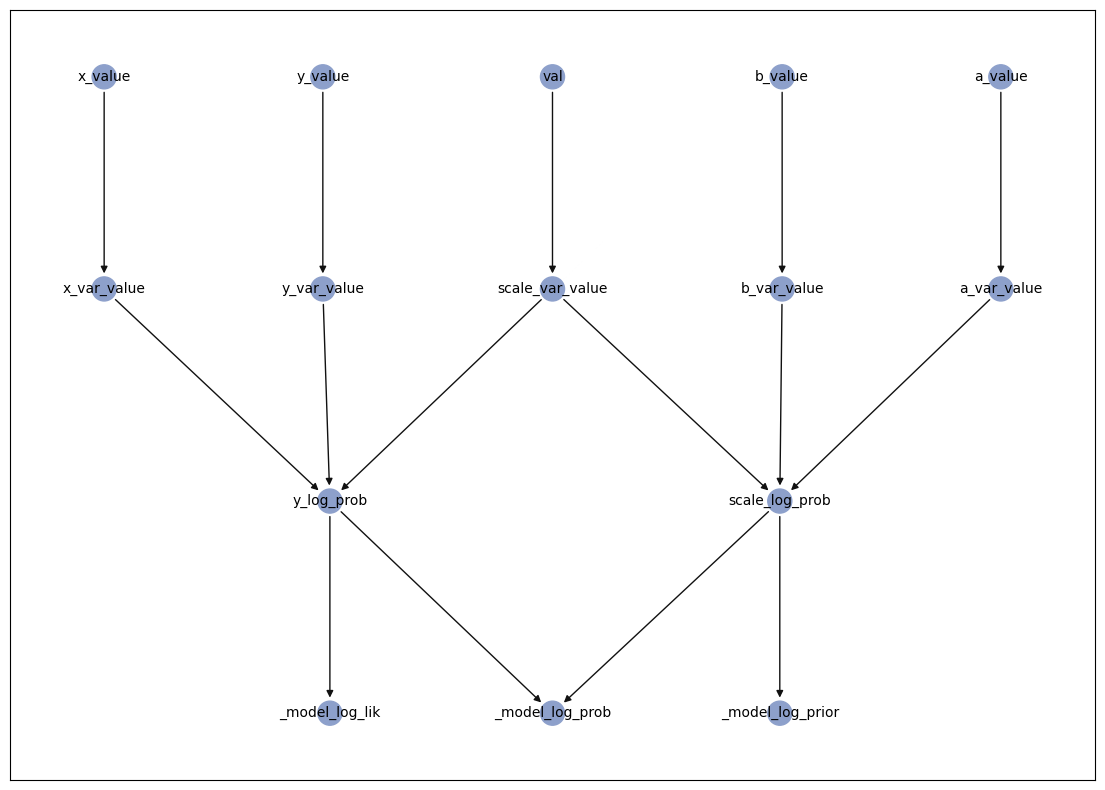

In [30]:
scale.value_node = lsl.Value(2.0, _name="val")
model.plot_nodes()

## Replace value node with float

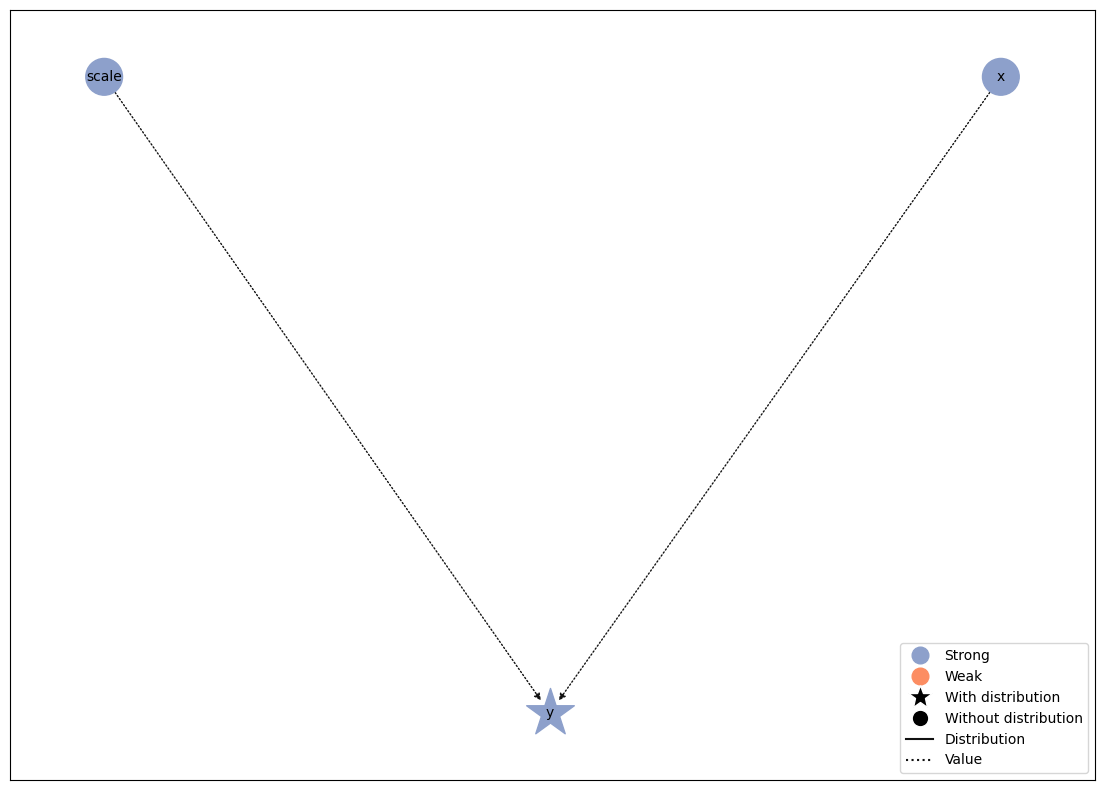

In [31]:
model.replace(scale, 1.0)
model.plot_vars()

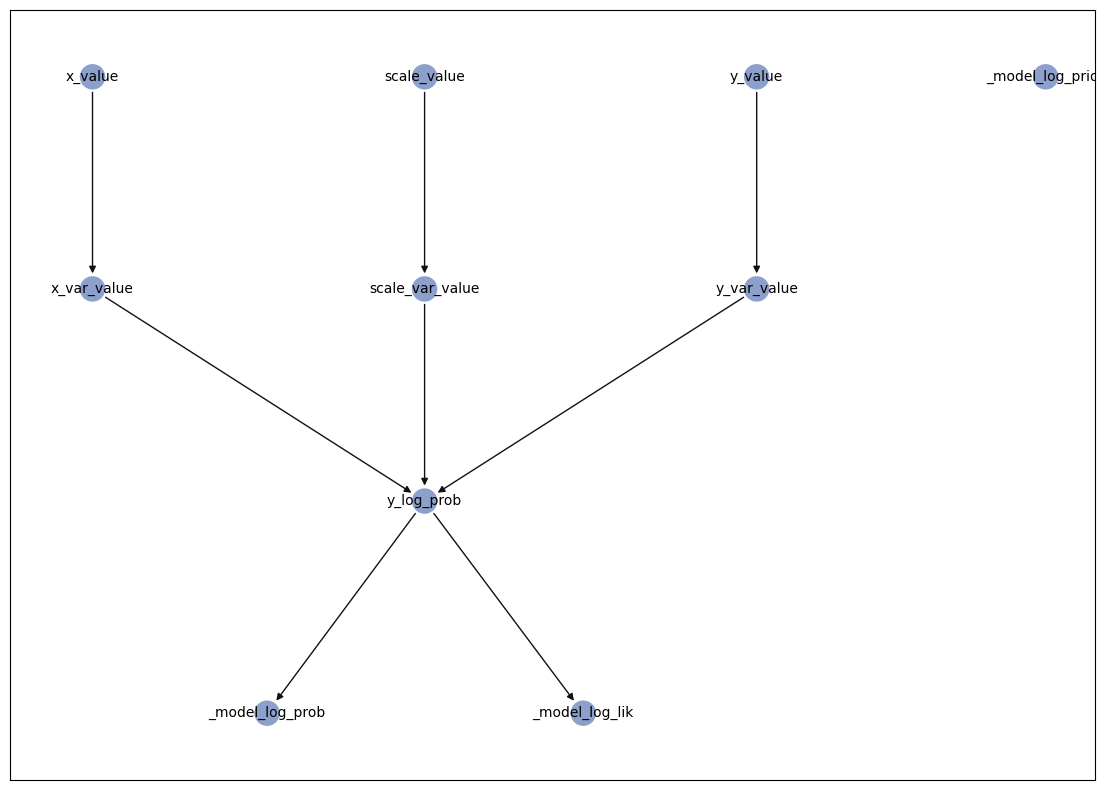

In [32]:
model.plot_nodes()

## Apply Var.biject

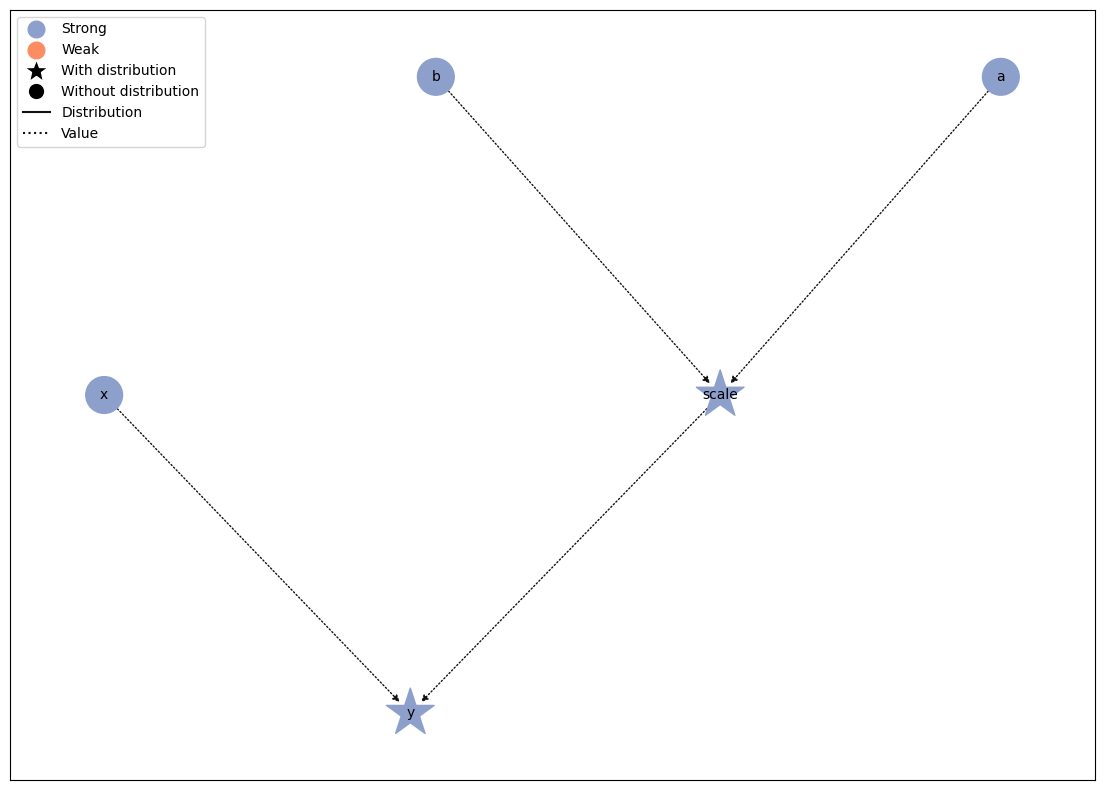

In [33]:
import tensorflow_probability.substrates.jax.bijectors as tfb

x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)
y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

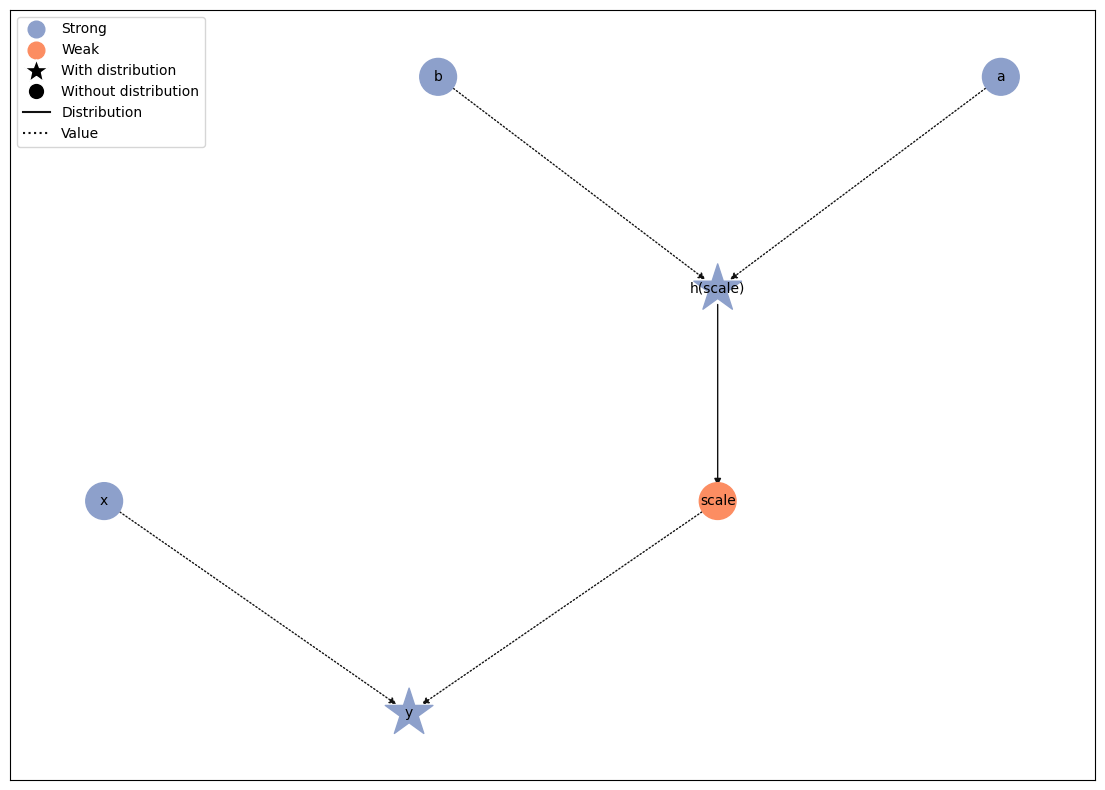

In [34]:
scale.biject(tfb.Exp())
model.plot_vars()

## Replace parent of weak Var with node

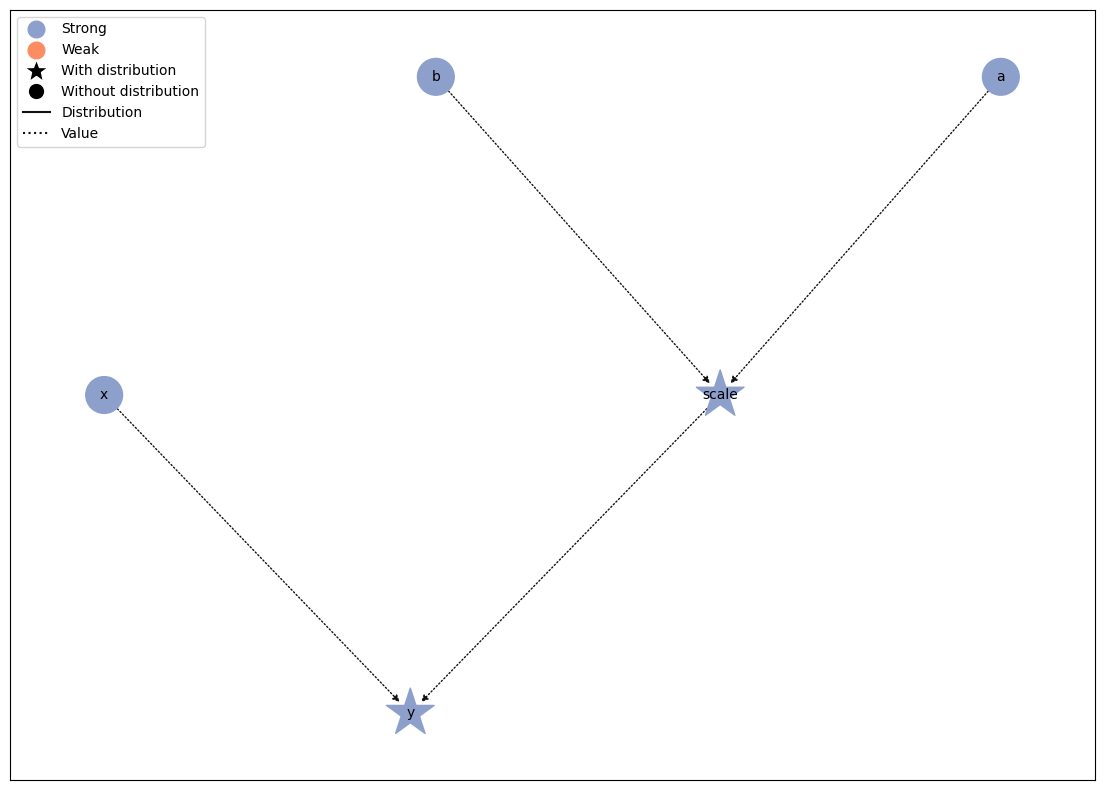

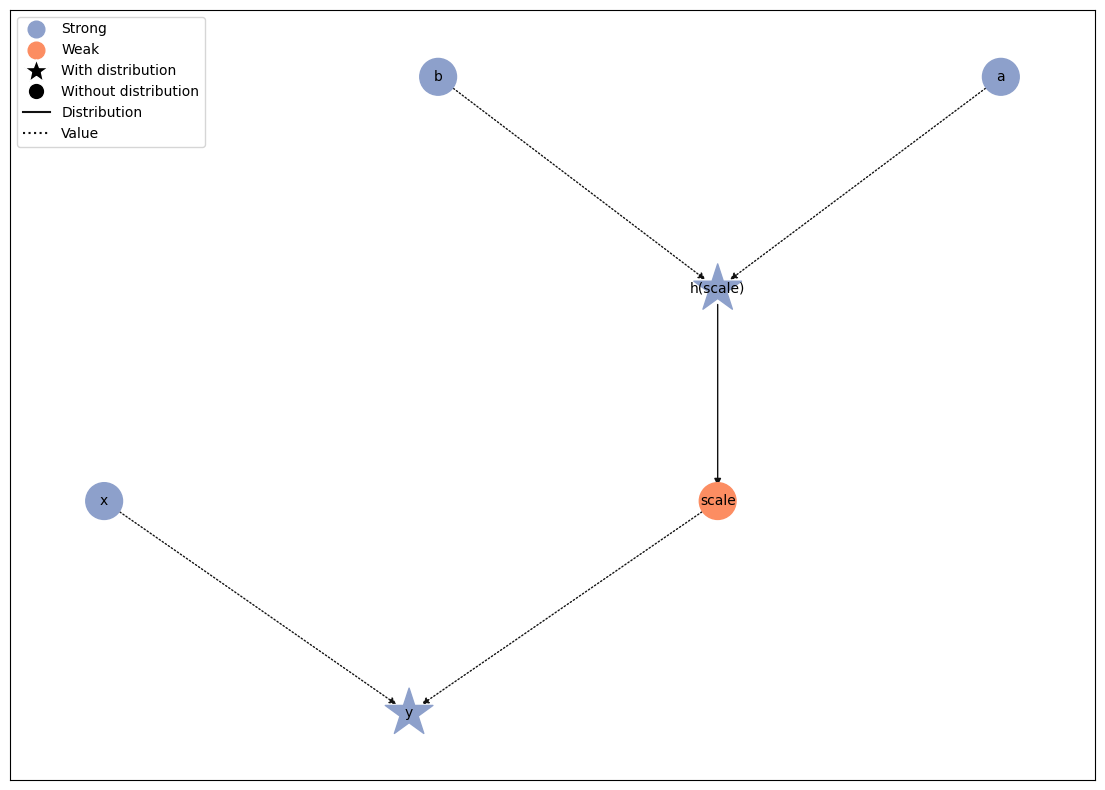

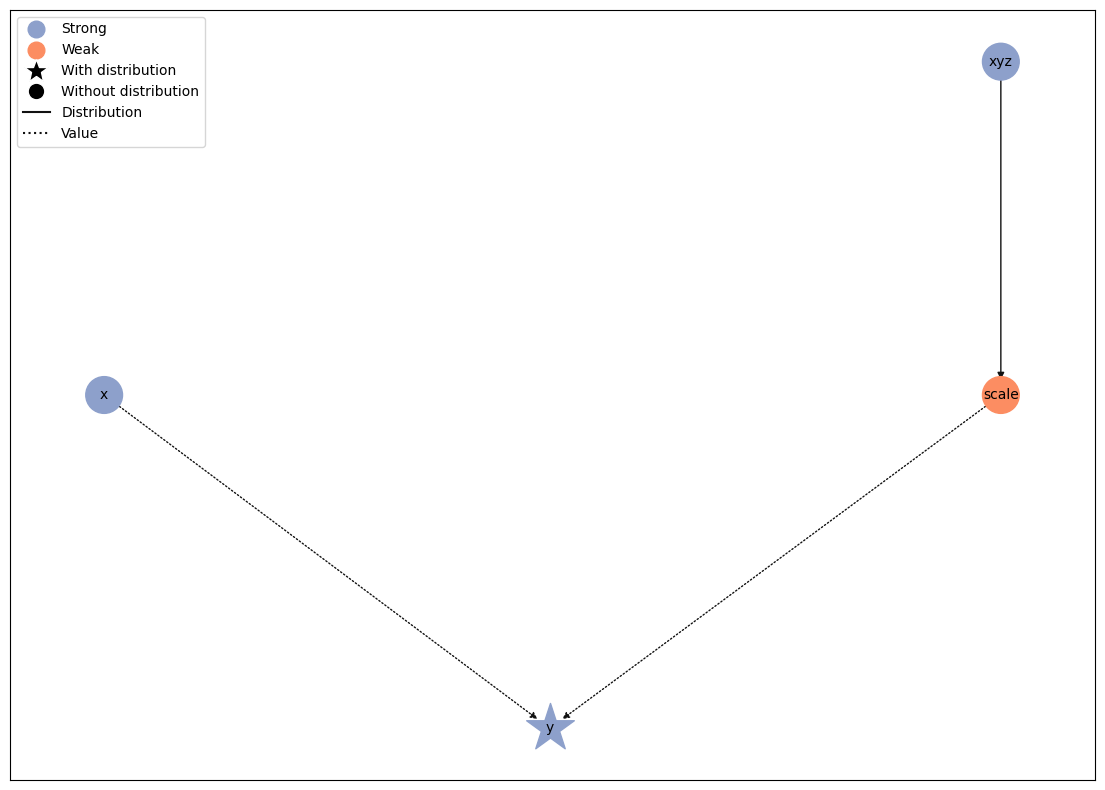

In [35]:
import tensorflow_probability.substrates.jax.bijectors as tfb

x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)
y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

scale.biject(tfb.Exp())
model.plot_vars()

model.replace("h(scale)", lsl.Var.new_value(0.0, name="xyz"))

model.plot_vars()

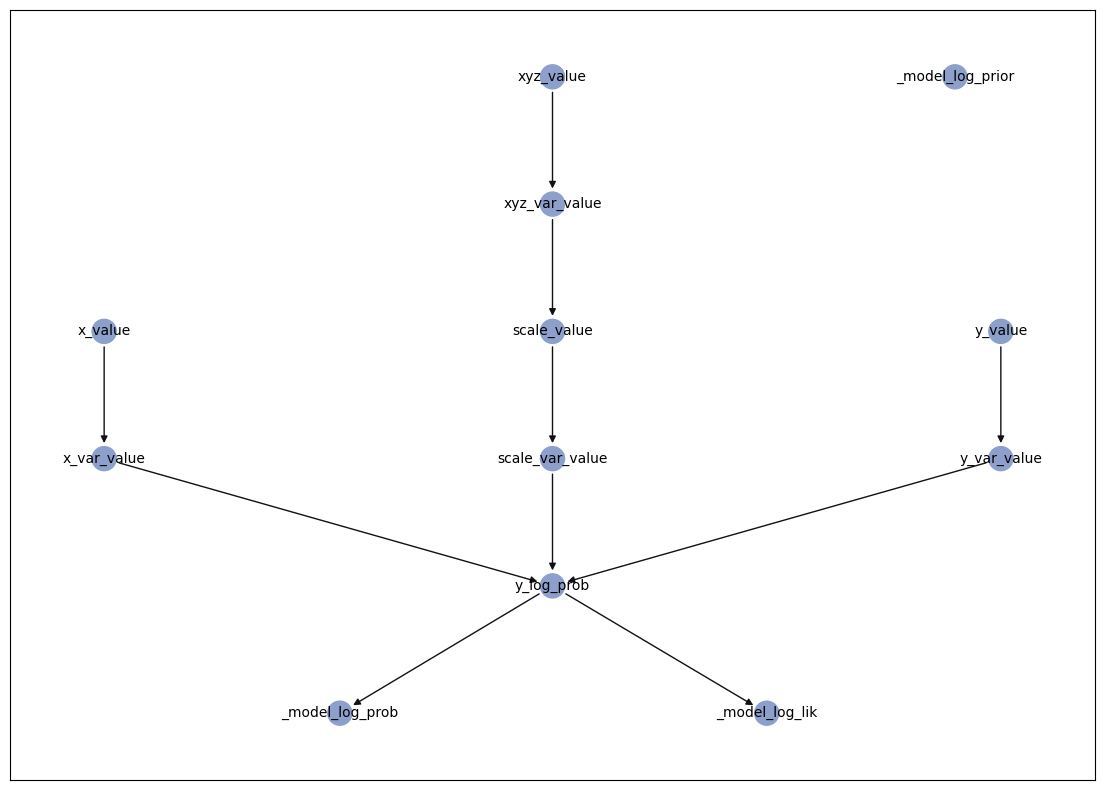

In [36]:
model.plot_nodes()

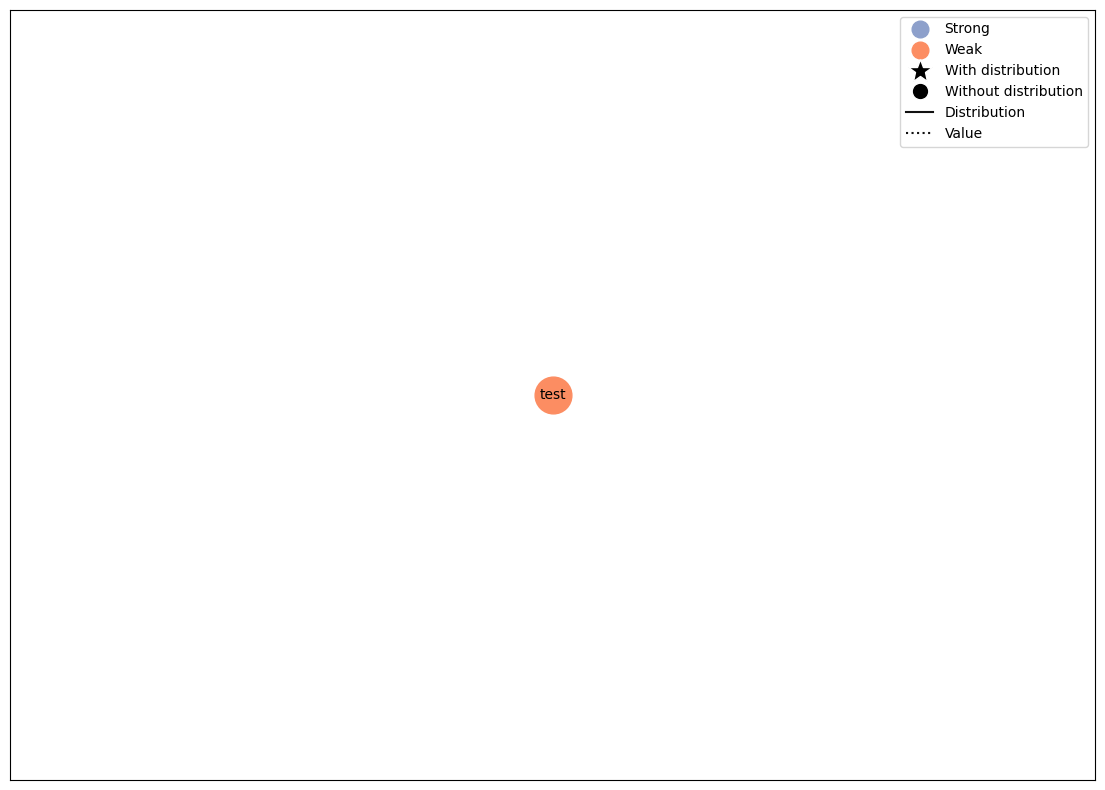

In [37]:
lsl.Var.new_calc(lambda x: x, 0.0, name="test").plot()

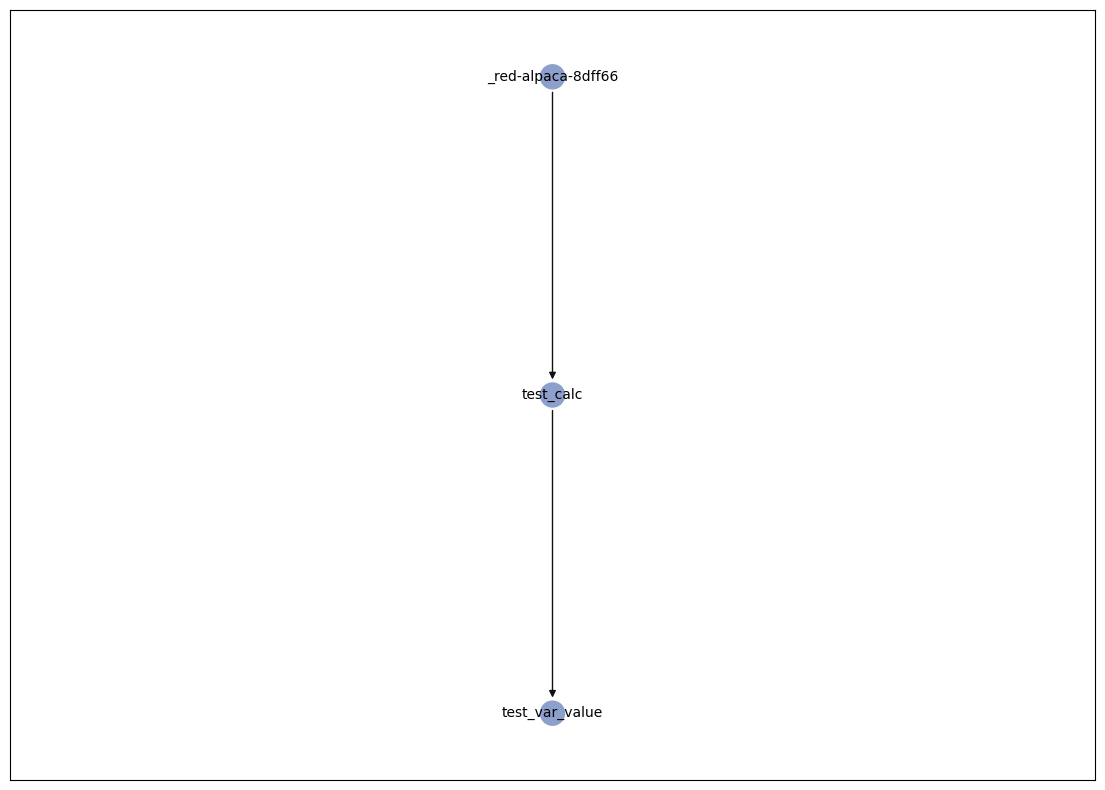

In [38]:
lsl.Var.new_calc(lambda x: x, 0.0, name="test").plot_nodes()

## Model.join

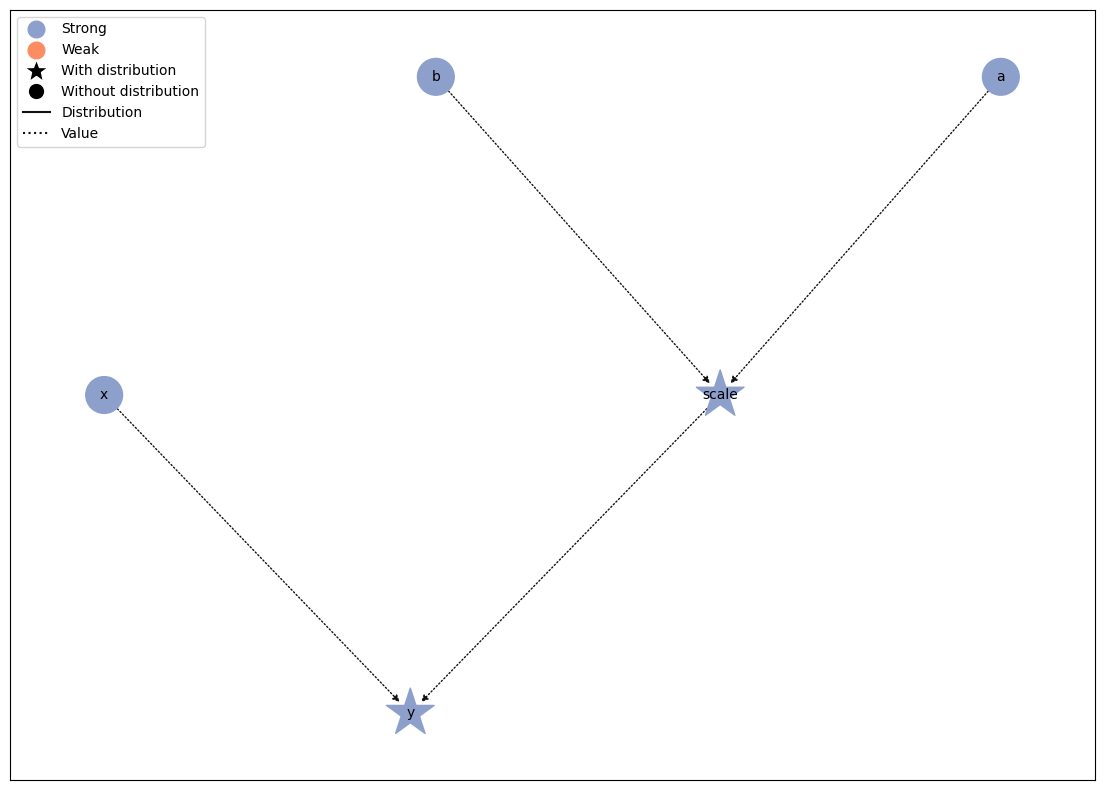

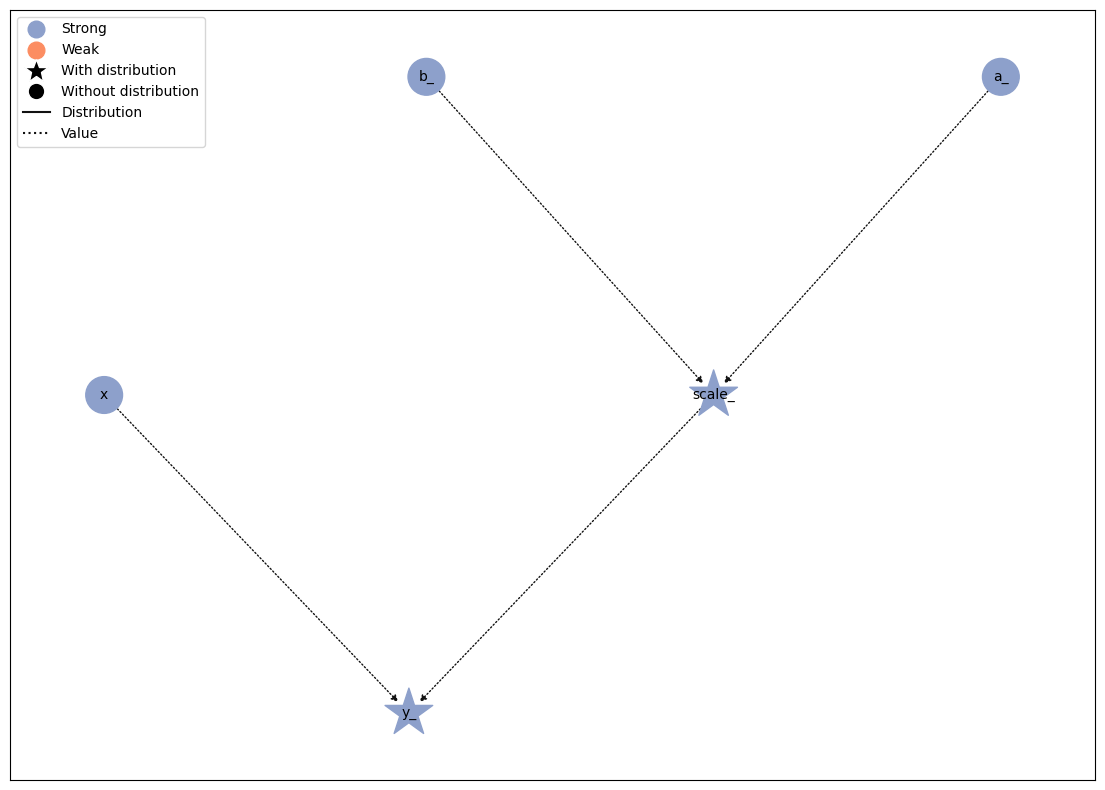

In [39]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)
y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=scale), name="y"
)

model = lsl.Model([y])
model.locked = False
model.plot_vars()

x_ = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale_ = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a_"),
        scale=lsl.Var.new_param(1.0, name="b_"),
    ),
    name="scale_",
)
y_ = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x_, scale=scale_), name="y_"
)

model_ = lsl.Model([y_])
model_.locked = False
model_.plot_vars()

In [40]:
model.join_by_all(model_, copy=True)

liesel.model.model - INFO - Joining by: x


Model(25 nodes, 9 vars)

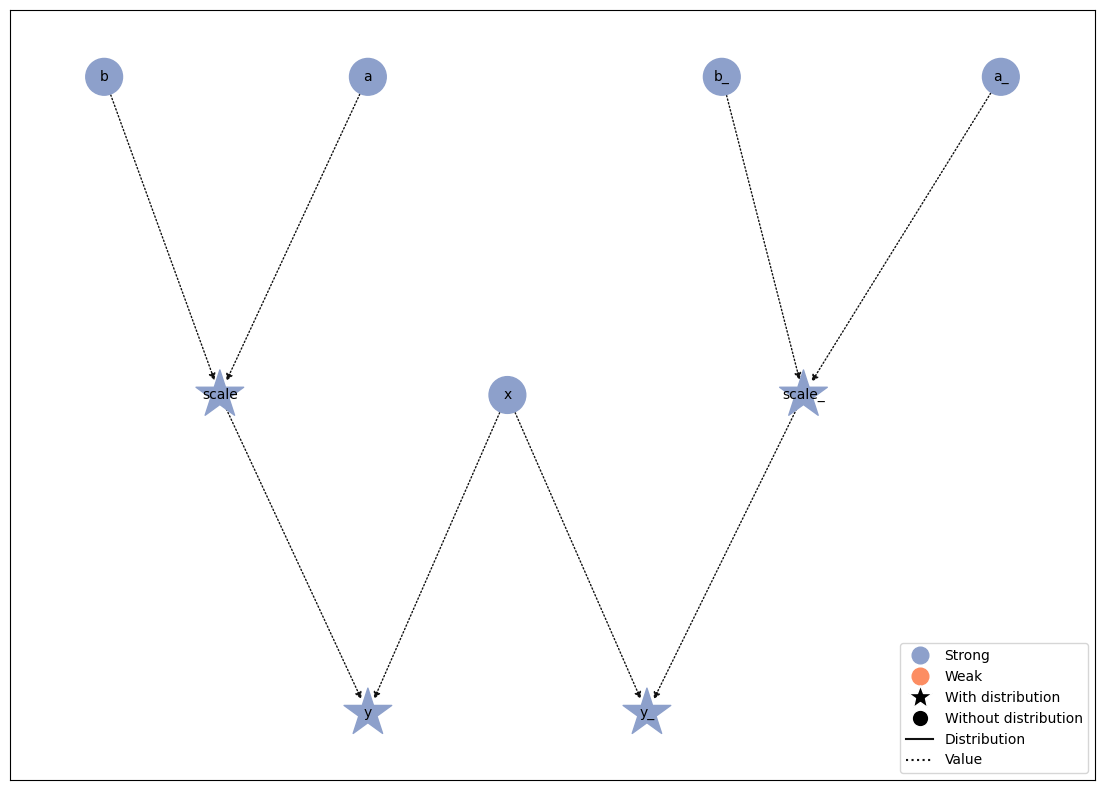

In [41]:
model.plot()

In [42]:
model_.vars

mappingproxy({'x': Var(name="x"),
              'b_': Var(name="b_"),
              'a_': Var(name="a_"),
              'scale_': Var(name="scale_"),
              'y_': Var(name="y_")})

In [43]:
model.join(model_)

liesel.model.model - INFO - x found in both models. Renaming to 'x.x' and 'x.y'.
liesel.model.model - INFO - b_ found in both models. Renaming to 'b_.x' and 'b_.y'.
liesel.model.model - INFO - a_ found in both models. Renaming to 'a_.x' and 'a_.y'.
liesel.model.model - INFO - scale_ found in both models. Renaming to 'scale_.x' and 'scale_.y'.
liesel.model.model - INFO - y_ found in both models. Renaming to 'y_.x' and 'y_.y'.


Model(37 nodes, 14 vars)

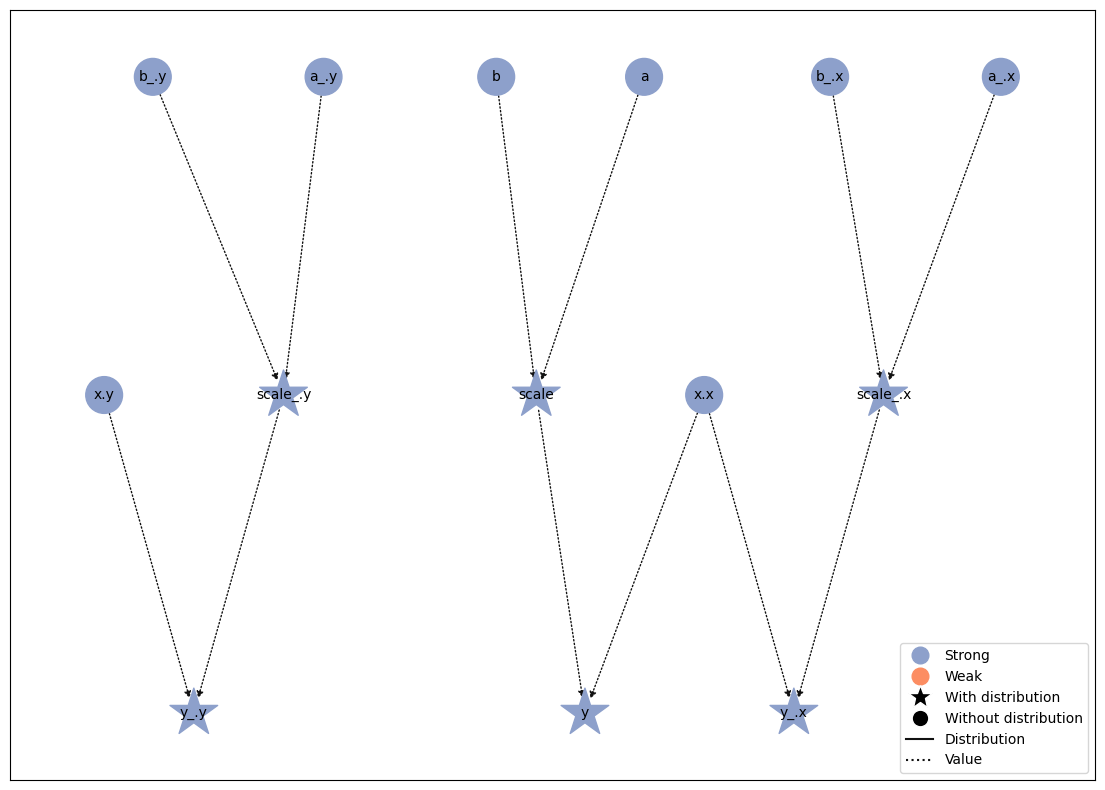

In [44]:
model.plot()

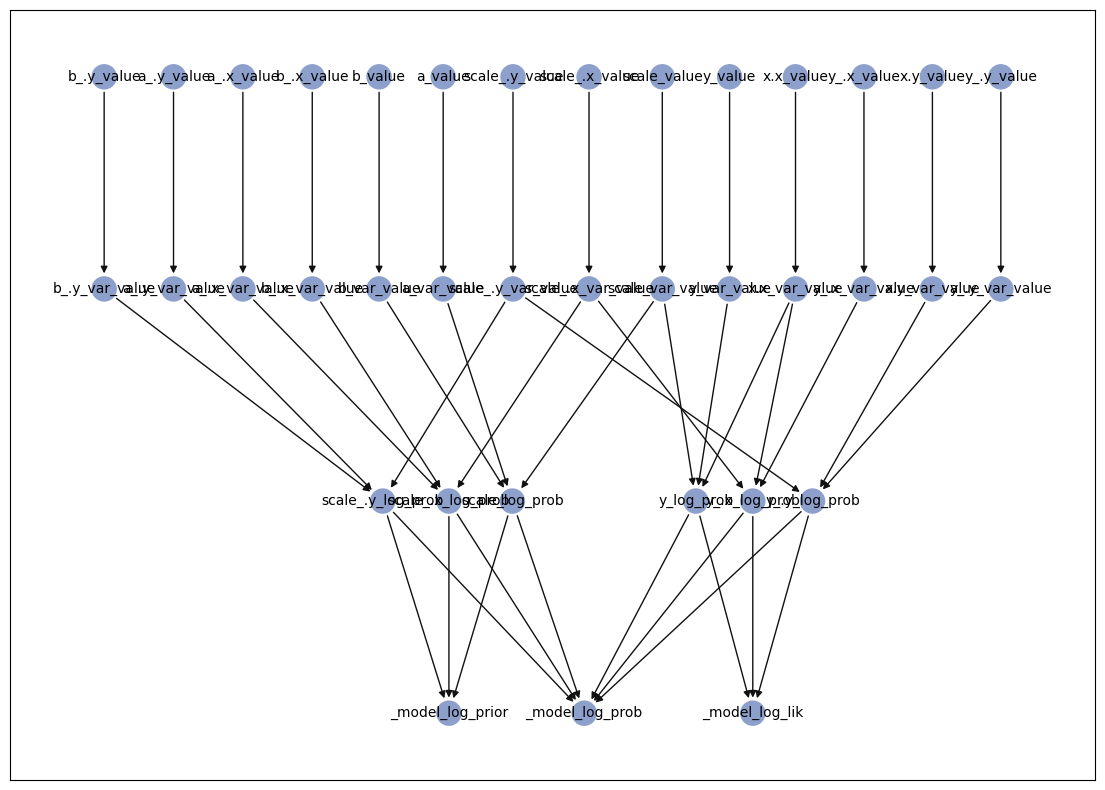

In [45]:
model.plot_nodes()